

# <table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>1.Chose a dataset from a domain of our choice
</b></font>
    </td>
  </tr>
</table>


**About the data**
* The data of these two games is anonymized, meaning there are no references to the names of players, teams or competitions.
* You'll see the data goes from 0 to 1 on each axis. The coordiante (0,0) is the top left, (1,1) is the bottom right, and (0.5,0.5) is the kick off point.
* The dimensions of the field are the same for both games: 105x68 meters.
* Tracking and event data are synchronized.





**Data Loading**

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
# Add the local directory '/content' to the Python path where data
sys.path.insert(0, '/content')

# Download sample raw events data from the Metrica Sports GitHub repository
!wget -P data/ https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawEventsData.csv


# Download sample raw tracking data for the away team and home team
!wget -P data/ https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv
!wget -P data/ https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv

# List the contents of the 'data/' directory to verify downloads
!ls data/


--2025-09-23 06:23:29--  https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawEventsData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139446 (136K) [text/plain]
Saving to: ‘data/Sample_Game_1_RawEventsData.csv’

Sample_Game_1_RawEv 100%[===================>] 136.18K  --.-KB/s    in 0.005s  

2025-09-23 06:23:29 (28.8 MB/s) - ‘data/Sample_Game_1_RawEventsData.csv’ saved [139446/139446]

--2025-09-23 06:23:29--  https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (ra

Loads the raw events dataset so we can inspect and process football match actions.

In [2]:
import pandas as pd

#Loading the from data folder in content
event_data = pd.read_csv("/content/data/Sample_Game_1_RawEventsData.csv")
tracking_data_away = pd.read_csv("/content/data/Sample_Game_1_RawTrackingData_Away_Team.csv")
tracking_data_home = pd.read_csv("/content/data/Sample_Game_1_RawTrackingData_Home_Team.csv")

# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Events Data Preprocessing
      </b></font>
    </td>
  </tr>
</table>



 <table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>2. Performed data cleaning using Python
</b></font>
    </td>
  </tr>
</table>
<br>

**Loading the Dataset:**
We begin by loading the raw football match events dataset

**File:** *Sample_Game_1_RawEventsData.csv*

**Purpose:** Contains detailed match events including passes, shots, start/end positions, timestamps, and team information.

**Goal:** Prepare this data for analysis by cleaning missing values, engineering meaningful features, and encoding categorical variables.

In [3]:
event_df = pd.read_csv("/content/data/Sample_Game_1_RawEventsData.csv")
event_df.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


**Flag Missing Data**

Creates flags to quickly identify rows with missing values and their percentage share.


*   Creating a summary row for missing data
*   A new DataFrame is created
*   Team: The label 'Total_Before_Cleaning' to indicate this is a summary row for the raw data before any cleaning
*   flag: The total number of rows with missing values
*   flag_percent: The percentage of rows with missing values in the entire DataFrame

In [4]:
# Calculating flags on raw data
event_df['flag'] = event_df.isnull().any(axis=1).astype(int)
event_df['flag_percent'] = round(event_df['flag'] * 100 / len(event_df), 2)

**Summary Row (Before Cleaning)**

Adds a summary row showing total missing data before cleaning for reference.

In [5]:
total_row_pre = pd.DataFrame({
    'Team': ['Total_Before_Cleaning'],
    'flag': [event_df['flag'].sum()],
    'flag_percent': [round(event_df['flag'].mean() * 100, 2)]
})
event_df = pd.concat([event_df, total_row_pre], ignore_index=True)

In [6]:
print(event_df.tail(5))

                       Team       Type       Subtype  Period  Start Frame  \
1741                   Home       PASS           NaN     2.0     143578.0   
1742                   Home  BALL LOST  INTERCEPTION     2.0     143598.0   
1743                   Away   RECOVERY       BLOCKED     2.0     143617.0   
1744                   Away   BALL OUT           NaN     2.0     143622.0   
1745  Total_Before_Cleaning        NaN           NaN     NaN          NaN   

      Start Time [s]  End Frame  End Time [s]      From       To  Start X  \
1741         5743.12   143593.0       5743.72  Player13  Player4     0.09   
1742         5743.92   143618.0       5744.72   Player4      NaN     0.13   
1743         5744.68   143617.0       5744.68  Player16      NaN     0.05   
1744         5744.88   143630.0       5745.20  Player16      NaN     0.05   
1745             NaN        NaN           NaN       NaN      NaN      NaN   

      Start Y  End X  End Y  flag  flag_percent  
1741     0.88   0.14   0

This code counts the number of missing (null) values in each column of event_df, but ignores any rows where the Team column contains "Total"—for example, the summary row we added for before-cleaning.

In [7]:
# To find the number of missing (null) values in the event_df DataFrame, excluding rows where the Team column contains the word "Total"
event_df.loc[~event_df['Team'].str.contains('Total', na=False)].isnull().sum()

,0
Team,0
Type,0
Subtype,953
Period,0
Start Frame,0
Start Time [s],0
End Frame,0
End Time [s],0
From,0
To,946


This code shows what percentage of data is missing in each column of event_df.

In [8]:
missing_percent = event_df.isnull().mean() * 100
print(missing_percent)

Team               0.000000
Type               0.057274
Subtype           54.639175
Period             0.057274
Start Frame        0.057274
Start Time [s]     0.057274
End Frame          0.057274
End Time [s]       0.057274
From               0.057274
To                54.238259
Start X            4.696449
Start Y            4.696449
End X             36.483391
End Y             36.483391
flag               0.000000
flag_percent       0.000000
dtype: float64


In [9]:
# Dropping rows which have missing start coordinates becuase the % was less
event_df = event_df.dropna(subset=['Start X', 'Start Y']).reset_index(drop=True)

We dropped rows with missing Start X or Start Y because these coordinates are essential to locate where an event began on the pitch, and since only a small percentage were missing, removing them prevents inaccurate analysis without significantly reducing data size.

In [10]:
event_df[event_df['Subtype'].isna()]['Type'].value_counts()

,count
Type,
PASS,757
RECOVERY,84
BALL LOST,51
BALL OUT,39
FAULT RECEIVED,22


The Subtype NaNs for PASS are probably normal (most passes may not have a more specific subtype). We could leave these as "UNKNOWN PASS" or "PASS" directly.

For RECOVERY, BALL LOST, BALL OUT and FAULT RECEIVED- those are already descriptive Type values — their Subtype may just be intentionally blank. So we  set them equal to the Type name for consistency.

In [11]:
event_df['Subtype'] = event_df.apply(
    lambda row: row['Type'] if pd.isna(row['Subtype']) else row['Subtype'],
    axis=1
)

In [12]:
event_df[event_df['To'].isna()]['Type'].value_counts()

,count
Type,
RECOVERY,278
BALL LOST,257
CHALLENGE,233
BALL OUT,51
SHOT,24
FAULT RECEIVED,22


We can group them into two categories:

Events where **TO** has no real meaning we are filling "Unknown_Receiver":
RECOVERY, BALL LOST, CHALLENGE,FAULT RECEIVED.

Events where **TO** might be gathered from the next step:

BALL OUT - sometimes another player takes the throw-in/free kick,
SHOT - sometimes a rebound or follow-up.


In [13]:
event_df['to_imputed'] = 0

for i in range(len(event_df) - 1):
    if pd.isna(event_df.loc[i, 'To']) and event_df.loc[i, 'Type'] in ['BALL OUT', 'SHOT']:
        next_row = event_df.loc[i+1]

        if (next_row['Team'] == event_df.loc[i, 'Team']) and \
           (abs(next_row['Start Time [s]'] - event_df.loc[i, 'End Time [s]']) <= 2):
            event_df.loc[i, 'To'] = next_row['From']
            event_df.loc[i, 'to_imputed'] = 1

event_df['To'] = event_df['To'].fillna('Unknown_Receiver')

**NOTE:** We will use the to_imputed column so the model can understand and learn from events where the recipient was unknown, which may tell us specific play types or match situations.

In [14]:
event_df[event_df[['End X', 'End Y']].isna().all(axis=1)]['Type'].value_counts()

,count
Type,
RECOVERY,278
CHALLENGE,233
BALL LOST,22
FAULT RECEIVED,22


In [15]:
static_events = ['RECOVERY', 'CHALLENGE', 'BALL LOST', 'FAULT RECEIVED']
mask = (
    event_df['Type'].isin(static_events) &
    (event_df['End X'].isna() | event_df['End Y'].isna())
)
event_df.loc[mask, ['End X', 'End Y']] = event_df.loc[mask, ['Start X', 'Start Y']].values

The event types (recovery, challenge, ball lost, fault received) usually occur at a specific point on the field, not while the ball is traveling a distance.

Filling End X and End Y with the same values as Start X and Start Y is realistic - because physically, the ball or player didn’t move between the “start” and “end” of the event.

In [16]:
event_df.isnull().sum()

,0
Team,0
Type,0
Subtype,0
Period,0
Start Frame,0
Start Time [s],0
End Frame,0
End Time [s],0
From,0
To,0


In [17]:
# Count total duplicate rows
event_df.duplicated().sum()

np.int64(0)

In [18]:
duplicate_count = event_df.duplicated(subset=['Team','Type','Subtype','Period','Start Frame','Start Time [s]',
                                        'End Frame','End Time [s]','From','To','Start X','Start Y','End X','End Y',
                                        'flag','flag_percent','to_imputed']).sum()
print(duplicate_count)

0







 <table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>3. Exploratory Data Analysis
    
</b></font>
    </td>
  </tr>
</table>




In [19]:
event_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Team            1664 non-null   object 
 1   Type            1664 non-null   object 
 2   Subtype         1664 non-null   object 
 3   Period          1664 non-null   float64
 4   Start Frame     1664 non-null   float64
 5   Start Time [s]  1664 non-null   float64
 6   End Frame       1664 non-null   float64
 7   End Time [s]    1664 non-null   float64
 8   From            1664 non-null   object 
 9   To              1664 non-null   object 
 10  Start X         1664 non-null   float64
 11  Start Y         1664 non-null   float64
 12  End X           1664 non-null   float64
 13  End Y           1664 non-null   float64
 14  flag            1664 non-null   int64  
 15  flag_percent    1664 non-null   float64
 16  to_imputed      1664 non-null   int64  
dtypes: float64(10), int64(2), object(

event_df.info() gives us a quick glance at the dataset — how many rows and columns we have, what type of data each column holds, and where values are missing. It’s like a quick health check before moving into analysis.

In [20]:
event_df.columns

Index(['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]',
       'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y',
       'End X', 'End Y', 'flag', 'flag_percent', 'to_imputed'],
      dtype='object')

Gives us a list of all column names in the dataset. It’s like reading the table of contents for your data, so you know what features are available to explore, or analyze next.

In [21]:
event_df.shape

(1664, 17)

Shows the dimensions of the dataset as (rows, columns).Eg. It’s like checking the size of a spreadsheet

In [22]:
#flag after cleaning
event_df['flag'] = event_df.isnull().any(axis=1).astype(int)

# Calculating overall flag percentage
event_df['flag_percent'] = event_df['flag'].sum() / len(event_df) * 100

In [23]:
# Create summary row
total_row = pd.DataFrame({
    'Team': ['Total'],
    'flag': [event_df['flag'].sum()],
    'flag_percent': [round(event_df['flag'].mean() * 100, 2)]
})

event_df = pd.concat([event_df, total_row], ignore_index=True)

In [24]:
print(event_df.tail(5))

       Team       Type       Subtype  Period  Start Frame  Start Time [s]  \
1660   Home       PASS          PASS     2.0     143578.0         5743.12   
1661   Home  BALL LOST  INTERCEPTION     2.0     143598.0         5743.92   
1662   Away   RECOVERY       BLOCKED     2.0     143617.0         5744.68   
1663   Away   BALL OUT      BALL OUT     2.0     143622.0         5744.88   
1664  Total        NaN           NaN     NaN          NaN             NaN   

      End Frame  End Time [s]      From                To  Start X  Start Y  \
1660   143593.0       5743.72  Player13           Player4     0.09     0.88   
1661   143618.0       5744.72   Player4  Unknown_Receiver     0.13     0.69   
1662   143617.0       5744.68  Player16  Unknown_Receiver     0.05     0.62   
1663   143630.0       5745.20  Player16  Unknown_Receiver     0.05     0.63   
1664        NaN           NaN       NaN               NaN      NaN      NaN   

      End X  End Y  flag  flag_percent  to_imputed  
1660   0.

This workflow flags rows with missing values, calculates the percentage of incomplete data, and creates a summary row for easy inspection. It’s a structured way to report data quality after cleaning.

In [25]:
# Saving file with flags
event_df.to_csv('/content/events_cleaned_with_flags.csv', index=False)

In [26]:
# Dropping flag columns and removing the last row (Total)
event_df = event_df.drop(columns=[col for col in ['flag','flag_percent'] if col in event_df.columns]).iloc[:-1].reset_index(drop=True)

We dropped the flag columns and the Total row because they were only used to track missing data during cleaning; removing them keeps the dataset clean and ensures modeling and visualizations aren’t affected by irrelevant or NaN-filled rows, which improves accuracy and avoids potential errors.

In [27]:
# Saving file without flags (for visualization, modeling, sharing)
event_df.to_csv('/content/events_cleaned.csv', index=False)

In [28]:
import pandas as pd
event_df = pd.read_csv('/content/events_cleaned.csv')

In [29]:
#Exploring the events data
event_df.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
0,Away,PASS,PASS,1.0,1.0,0.04,3.0,0.12,Player19,Player21,0.45,0.39,0.55,0.43,0.0
1,Away,PASS,PASS,1.0,3.0,0.12,17.0,0.68,Player21,Player15,0.55,0.43,0.58,0.21,0.0
2,Away,PASS,PASS,1.0,45.0,1.80,61.0,2.44,Player15,Player19,0.55,0.19,0.45,0.31,0.0
3,Away,PASS,PASS,1.0,77.0,3.08,96.0,3.84,Player19,Player21,0.45,0.32,0.49,0.47,0.0
4,Away,PASS,PASS,1.0,191.0,7.64,217.0,8.68,Player21,Player22,0.40,0.73,0.32,0.98,0.0


We will see the "Type" field to see different events like pass, set pieces, shots etc. that has been in the match.

In [30]:
event_df['Type'].value_counts()

,count
Type,
PASS,799
RECOVERY,278
BALL LOST,257
CHALLENGE,233
BALL OUT,51
SHOT,24
FAULT RECEIVED,22


The positions (x,y coordinates) of each event are in between 0 to 1. These are according to the Metrica Coordinate System which is actually like Cartesian coordinate system. Here the origin (0,0) is at the bottom left corner of the field.

We will convert these coordinates into actual size of football fields (length 106m, width 68m). Also the origin (0,0) will be at the center of the field.

In [31]:
def to_metric_coordinates(data,field_dimen=(106.,68.)):
    #Converts (x,y) positions from Metrica Unit (cartesian) to meters. Origin at the center (0,0)
    x_columns = [c for c in data.columns if c[-1].lower()=="x"]
    y_columns = [c for c in data.columns if c[-1].lower()=="y"]
    data[x_columns]=(data[x_columns]-0.5)*field_dimen[0]
    data[y_columns]=(data[y_columns]-0.5)*field_dimen[1]
    return data

In [32]:
event_df=to_metric_coordinates(event_df)
event_df.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
0,Away,PASS,PASS,1.0,1.0,0.04,3.0,0.12,Player19,Player21,-5.3,-7.48,5.30,-4.76,0.0
1,Away,PASS,PASS,1.0,3.0,0.12,17.0,0.68,Player21,Player15,5.3,-4.76,8.48,-19.72,0.0
2,Away,PASS,PASS,1.0,45.0,1.80,61.0,2.44,Player15,Player19,5.3,-21.08,-5.30,-12.92,0.0
3,Away,PASS,PASS,1.0,77.0,3.08,96.0,3.84,Player19,Player21,-5.3,-12.24,-1.06,-2.04,0.0
4,Away,PASS,PASS,1.0,191.0,7.64,217.0,8.68,Player21,Player22,-10.6,15.64,-19.08,32.64,0.0


Now we will be dividing the events data into home and away events data to explore more

In [33]:
home_events= event_df[event_df['Team']=="Home"]
away_events= event_df[event_df['Team']=="Away"]

In [34]:
home_events['Type'].value_counts()

,count
Type,
PASS,437
RECOVERY,135
BALL LOST,129
CHALLENGE,118
SHOT,18
BALL OUT,18
FAULT RECEIVED,15


In [35]:
away_events['Type'].value_counts()

,count
Type,
PASS,362
RECOVERY,143
BALL LOST,128
CHALLENGE,115
BALL OUT,33
FAULT RECEIVED,7
SHOT,6


Let's dig into "shots" data from home and away team

In [36]:
shots=event_df[event_df['Type']=="SHOT"]
shots.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
32,Home,SHOT,HEAD-ON TARGET-GOAL,1.0,2289.0,91.56,2309.0,92.36,Player9,Unknown_Receiver,44.52,-2.04,54.06,3.40,0.0
74,Home,SHOT,OFF TARGET-OUT,1.0,5923.0,236.92,5953.0,238.12,Player10,Unknown_Receiver,36.04,-15.64,57.24,6.80,0.0
105,Away,SHOT,OFF TARGET-OUT,1.0,7753.0,310.12,7789.0,311.56,Player21,Unknown_Receiver,-31.80,-13.60,-57.24,10.20,0.0
128,Home,SHOT,ON TARGET-SAVED,1.0,9628.0,385.12,9632.0,385.28,Player8,Unknown_Receiver,48.76,-8.84,50.88,-2.72,0.0
225,Home,SHOT,HEAD-OFF TARGET-OUT,1.0,18270.0,730.80,18301.0,732.04,Player8,Unknown_Receiver,46.64,3.40,56.18,7.48,0.0


In [37]:
home_shots = home_events[home_events.Type=='SHOT']
home_shots.head(10)

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
32,Home,SHOT,HEAD-ON TARGET-GOAL,1.0,2289.0,91.56,2309.0,92.36,Player9,Unknown_Receiver,44.52,-2.04,54.06,3.40,0.0
74,Home,SHOT,OFF TARGET-OUT,1.0,5923.0,236.92,5953.0,238.12,Player10,Unknown_Receiver,36.04,-15.64,57.24,6.80,0.0
128,Home,SHOT,ON TARGET-SAVED,1.0,9628.0,385.12,9632.0,385.28,Player8,Unknown_Receiver,48.76,-8.84,50.88,-2.72,0.0
225,Home,SHOT,HEAD-OFF TARGET-OUT,1.0,18270.0,730.80,18301.0,732.04,Player8,Unknown_Receiver,46.64,3.40,56.18,7.48,0.0
344,Home,SHOT,HEAD-OFF TARGET-OUT,1.0,26608.0,1064.32,26636.0,1065.44,Player8,Unknown_Receiver,47.70,2.04,56.18,-2.04,0.0
405,Home,SHOT,OFF TARGET-OUT,1.0,31190.0,1247.60,31235.0,1249.40,Player7,Unknown_Receiver,26.50,-8.84,58.30,6.12,0.0
624,Home,SHOT,HEAD-ON TARGET-SAVED,1.0,53695.0,2147.80,53707.0,2148.28,Player8,Unknown_Receiver,46.64,1.36,53.00,2.72,0.0
629,Home,SHOT,BLOCKED,1.0,53775.0,2151.00,53775.0,2151.00,Player5,Unknown_Receiver,38.16,14.96,41.34,15.64,0.0
689,Home,SHOT,OFF TARGET-OUT,1.0,57668.0,2306.72,57740.0,2309.60,Player7,Unknown_Receiver,32.86,15.64,55.12,-12.92,0.0
732,Home,SHOT,OFF TARGET-OUT,1.0,62792.0,2511.68,62847.0,2513.88,Player10,Unknown_Receiver,22.26,1.36,55.12,-15.64,0.0


In [38]:
away_shots = away_events[away_events.Type=='SHOT']
away_shots.head(10)

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
105,Away,SHOT,OFF TARGET-OUT,1.0,7753.0,310.12,7789.0,311.56,Player21,Unknown_Receiver,-31.80,-13.60,-57.24,10.20,0.0
240,Away,SHOT,ON TARGET-SAVED,1.0,19470.0,778.80,19483.0,779.32,Player24,Unknown_Receiver,-39.22,-8.84,-50.88,-1.36,0.0
891,Away,SHOT,ON TARGET-SAVED,2.0,75262.0,3010.48,75284.0,3011.36,Player19,Unknown_Receiver,27.56,4.76,51.94,-1.36,0.0
1261,Away,SHOT,ON TARGET-SAVED,2.0,108611.0,4344.44,108628.0,4345.12,Player27,Unknown_Receiver,44.52,-14.96,51.94,0.68,0.0
1455,Away,SHOT,OFF TARGET-OUT,2.0,124755.0,4990.20,124775.0,4991.00,Player23,Unknown_Receiver,37.10,-6.12,56.18,-5.44,0.0
1572,Away,SHOT,OFF TARGET-OUT,2.0,134041.0,5361.64,134076.0,5363.04,Player28,Unknown_Receiver,24.38,10.20,55.12,9.52,0.0


Subtype column is the result of the SHOT. Let's explore "Subtype"

In [39]:
home_shots['Subtype'].value_counts()

,count
Subtype,
OFF TARGET-OUT,6
ON TARGET-GOAL,2
ON TARGET-SAVED,2
HEAD-OFF TARGET-OUT,2
HEAD-ON TARGET-SAVED,2
HEAD-ON TARGET-GOAL,1
BLOCKED,1
HEAD-WOODWORK-OUT,1
OFF TARGET,1


In [40]:
away_shots['Subtype'].value_counts()

,count
Subtype,
OFF TARGET-OUT,3
ON TARGET-SAVED,3


Now let's find that which player took the shots from the "From" field

In [41]:
home_shots['From'].value_counts()

,count
From,
Player9,4
Player10,4
Player8,4
Player7,2
Player5,2
Player12,1
Player14,1


In [42]:
away_shots['From'].value_counts()

,count
From,
Player21,1
Player24,1
Player19,1
Player27,1
Player23,1
Player28,1


Now, we are going to see the events when "goal" happened

In [43]:
home_goals = home_shots[home_shots['Subtype'].str.contains('-GOAL')].copy()
home_goals

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
32,Home,SHOT,HEAD-ON TARGET-GOAL,1.0,2289.0,91.56,2309.0,92.36,Player9,Unknown_Receiver,44.52,-2.04,54.06,3.40,0.0
1056,Home,SHOT,ON TARGET-GOAL,2.0,90005.0,3600.20,90026.0,3601.04,Player10,Unknown_Receiver,-44.52,-12.92,-53.00,2.72,0.0
1150,Home,SHOT,ON TARGET-GOAL,2.0,99032.0,3961.28,99046.0,3961.84,Player9,Unknown_Receiver,-50.88,2.72,-54.06,0.68,0.0


Visualization of the data above

First we start with plotting the football field where we will visualize the data

In [44]:
def plot_pitch( field_dimen = (106.0,68.0), field_color ='green', linewidth=2, markersize=20):
    """ plot_pitch

    Plots a soccer pitch. All distance units converted to meters.

    Parameters
    -----------
        field_dimen: (length, width) of field in meters. Default is (106,68)
        field_color: color of field. options are {'green','white'}
        linewidth  : width of lines. default = 2
        markersize : size of markers (e.g. penalty spot, centre spot, posts). default = 20

    Returrns
    -----------
       fig,ax : figure and aixs objects (so that other data can be plotted onto the pitch)
    """
    fig,ax = plt.subplots(figsize=(12,8)) # create a figure
    # decide what color we want the field to be. Default is green, but can also choose white
    if field_color=='green':
        ax.set_facecolor('mediumseagreen')
        lc = 'whitesmoke' # line color
        pc = 'w' # 'spot' colors
    elif field_color=='white':
        lc = 'k'
        pc = 'k'
    # ALL DIMENSIONS IN m
    border_dimen = (3,3) # include a border around of the field of width 3m
    meters_per_yard = 0.9144 # unit conversion from yards to meters
    half_pitch_length = field_dimen[0]/2. # length of half pitch
    half_pitch_width = field_dimen[1]/2. # width of half pitch
    signs = [-1,1]
    # Soccer field dimensions typically defined in yards, so we need to convert to meters
    goal_line_width = 8*meters_per_yard
    box_width = 20*meters_per_yard
    box_length = 6*meters_per_yard
    area_width = 44*meters_per_yard
    area_length = 18*meters_per_yard
    penalty_spot = 12*meters_per_yard
    corner_radius = 1*meters_per_yard
    D_length = 8*meters_per_yard
    D_radius = 10*meters_per_yard
    D_pos = 12*meters_per_yard
    centre_circle_radius = 10*meters_per_yard
    # plot half way line # center circle
    ax.plot([0,0],[-half_pitch_width,half_pitch_width],lc,linewidth=linewidth)
    ax.scatter(0.0,0.0,marker='o',facecolor=lc,linewidth=0,s=markersize)
    y = np.linspace(-1,1,50)*centre_circle_radius
    x = np.sqrt(centre_circle_radius**2-y**2)
    ax.plot(x,y,lc,linewidth=linewidth)
    ax.plot(-x,y,lc,linewidth=linewidth)
    for s in signs: # plots each line seperately
        # plot pitch boundary
        ax.plot([-half_pitch_length,half_pitch_length],[s*half_pitch_width,s*half_pitch_width],lc,linewidth=linewidth)
        ax.plot([s*half_pitch_length,s*half_pitch_length],[-half_pitch_width,half_pitch_width],lc,linewidth=linewidth)
        # goal posts & line
        ax.plot( [s*half_pitch_length,s*half_pitch_length],[-goal_line_width/2.,goal_line_width/2.],pc+'s',markersize=6*markersize/20.,linewidth=linewidth)
        # 6 yard box
        ax.plot([s*half_pitch_length,s*half_pitch_length-s*box_length],[box_width/2.,box_width/2.],lc,linewidth=linewidth)
        ax.plot([s*half_pitch_length,s*half_pitch_length-s*box_length],[-box_width/2.,-box_width/2.],lc,linewidth=linewidth)
        ax.plot([s*half_pitch_length-s*box_length,s*half_pitch_length-s*box_length],[-box_width/2.,box_width/2.],lc,linewidth=linewidth)
        # penalty area
        ax.plot([s*half_pitch_length,s*half_pitch_length-s*area_length],[area_width/2.,area_width/2.],lc,linewidth=linewidth)
        ax.plot([s*half_pitch_length,s*half_pitch_length-s*area_length],[-area_width/2.,-area_width/2.],lc,linewidth=linewidth)
        ax.plot([s*half_pitch_length-s*area_length,s*half_pitch_length-s*area_length],[-area_width/2.,area_width/2.],lc,linewidth=linewidth)
        # penalty spot
        ax.scatter(s*half_pitch_length-s*penalty_spot,0.0,marker='o',facecolor=lc,linewidth=0,s=markersize)
        # corner flags
        y = np.linspace(0,1,50)*corner_radius
        x = np.sqrt(corner_radius**2-y**2)
        ax.plot(s*half_pitch_length-s*x,-half_pitch_width+y,lc,linewidth=linewidth)
        ax.plot(s*half_pitch_length-s*x,half_pitch_width-y,lc,linewidth=linewidth)
        # draw the D
        y = np.linspace(-1,1,50)*D_length # D_length is the chord of the circle that defines the D
        x = np.sqrt(D_radius**2-y**2)+D_pos
        ax.plot(s*half_pitch_length-s*x,y,lc,linewidth=linewidth)

    # remove axis labels and ticks
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    # set axis limits
    xmax = field_dimen[0]/2. + border_dimen[0]
    ymax = field_dimen[1]/2. + border_dimen[1]
    ax.set_xlim([-xmax,xmax])
    ax.set_ylim([-ymax,ymax])
    ax.set_axisbelow(True)
    return fig,ax

First shot is in 32nd index. The "red" dot is the point of the field from where the shot was taken

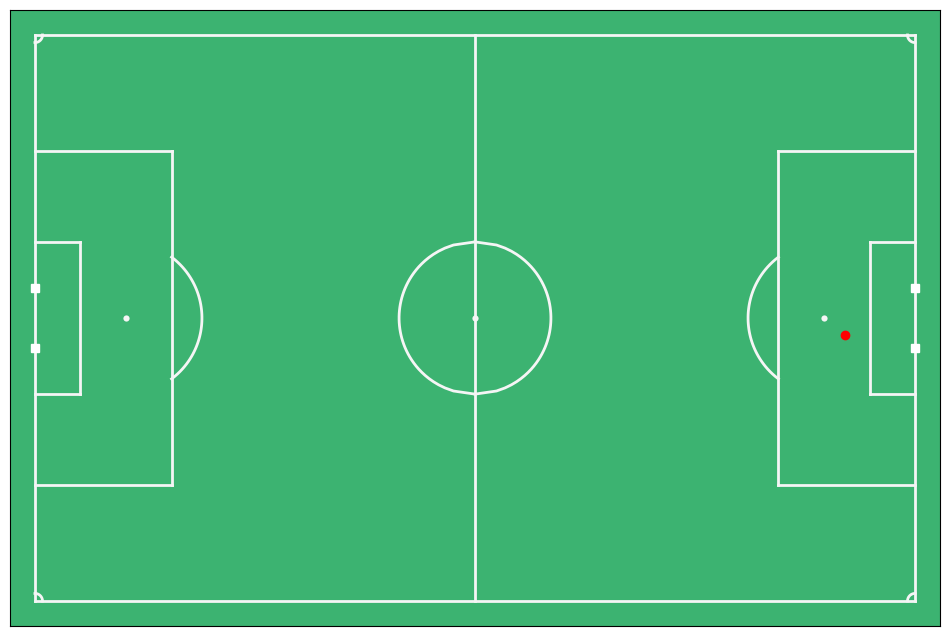

In [45]:
import matplotlib.pyplot as plt
import numpy as np

fig,ax=plot_pitch()
ax.plot(event_df.loc[32]['Start X'],event_df.loc[32]['Start Y'],'ro')

Now we will see that, to which direction the shot was taken

Text(44.52, -2.040000000000002, '')

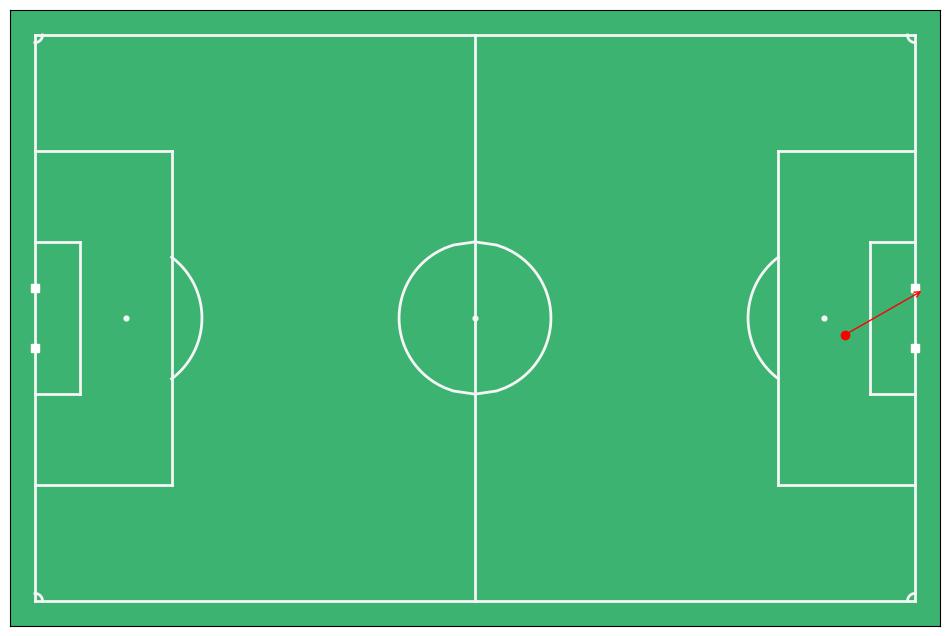

In [46]:
fig,ax=plot_pitch()
ax.plot(event_df.loc[32]['Start X'],event_df.loc[32]['Start Y'],'ro')
ax.annotate("",xy=event_df.loc[32][['End X','End Y']], xytext = event_df.loc[32][['Start X','Start Y']],alpha=0.1,arrowprops=dict(arrowstyle="->",color="r"))

Plotting the passes that lead to goal creation.

As we saw that the goal happened at 32nd index. let's see some previous indexes to see from there the home team got the ball

In [47]:
event_df[20:35]

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,to_imputed
20,Away,PASS,PASS,1.0,834.0,33.36,881.0,35.24,Player20,Player22,3.18,2.04,-6.36,28.56,0.0
21,Away,PASS,PASS,1.0,976.0,39.04,1010.0,40.40,Player22,Player17,-14.84,31.28,-2.12,24.48,0.0
22,Away,BALL LOST,INTERCEPTION,1.0,1110.0,44.40,1134.0,45.36,Player17,Unknown_Receiver,-8.48,19.72,-20.14,23.12,0.0
23,Home,RECOVERY,INTERCEPTION,1.0,1134.0,45.36,1134.0,45.36,Player5,Unknown_Receiver,-19.08,26.52,-19.08,26.52,0.0
24,Home,PASS,HEAD,1.0,1134.0,45.36,1154.0,46.16,Player5,Player6,-19.08,26.52,-20.14,19.04,0.0
25,Home,PASS,PASS,1.0,1154.0,46.16,1177.0,47.08,Player6,Player10,-20.14,19.04,-9.54,16.32,0.0
26,Home,PASS,PASS,1.0,1226.0,49.04,1266.0,50.64,Player10,Player8,-4.24,12.24,6.36,-10.88,0.0
27,Home,BALL LOST,INTERCEPTION,1.0,1370.0,54.80,1375.0,55.00,Player8,Unknown_Receiver,38.16,-16.32,40.28,-14.96,0.0
28,Away,RECOVERY,INTERCEPTION,1.0,1374.0,54.96,1374.0,54.96,Player15,Unknown_Receiver,39.22,-14.28,39.22,-14.28,0.0
29,Away,BALL OUT,BALL OUT,1.0,1374.0,54.96,1425.0,57.00,Player15,Unknown_Receiver,39.22,-14.28,58.30,-22.44,0.0


In [48]:
# plot event function
def plot_events( events, figax=None, field_dimen = (106.0,68), indicators = ['Marker','Arrow'], color='r', marker_style = 'o', alpha = 0.5, annotate=False):
    """ plot_events( events )

    Plots Metrica event positions on a football pitch. event data can be a single or several rows of a data frame. All distances should be in meters.

    Parameters
    -----------
        events: row (i.e. instant) of the home team tracking data frame
        fig,ax: Can be used to pass in the (fig,ax) objects of a previously generated pitch. Set to (fig,ax) to use an existing figure, or None (the default) to generate a new pitch plot,
        field_dimen: tuple containing the length and width of the pitch in meters. Default is (106,68)
        indicators: List containing choices on how to plot the event. 'Marker' places a marker at the 'Start X/Y' location of the event; 'Arrow' draws an arrow from the start to end locations. Can choose one or both.
        color: color of indicator. Default is 'r' (red)
        marker_style: Marker type used to indicate the event position. Default is 'o' (filled ircle).
        alpha: alpha of event marker. Default is 0.5
        annotate: Boolean determining whether text annotation from event data 'Type' and 'From' fields is shown on plot. Default is False.

    Returrns
    -----------
       fig,ax : figure and aixs objects (so that other data can be plotted onto the pitch)
    """
    if figax is None: # create new pitch
        fig,ax = plot_pitch( field_dimen = field_dimen )
    else: # overlay on a previously generated pitch
        fig,ax = figax
    for i,row in events.iterrows():
        if 'Marker' in indicators:
            ax.plot(  row['Start X'], row['Start Y'], color+marker_style, alpha=alpha )
        if 'Arrow' in indicators:
            ax.annotate("", xy=row[['End X','End Y']], xytext=row[['Start X','Start Y']], alpha=alpha, arrowprops=dict(alpha=alpha,width=0.5,headlength=4.0,headwidth=4.0,color=color),annotation_clip=False)
        if annotate:
            textstring = row['Type'] + ': ' + row['From']
            ax.text( row['Start X'], row['Start Y'], textstring, fontsize=10, color=color)
    return fig,ax

From this plotting, it's a bit tricky to say from where the passing started as the event dataset doesn't have the times when the player had the ball and ran with ball

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

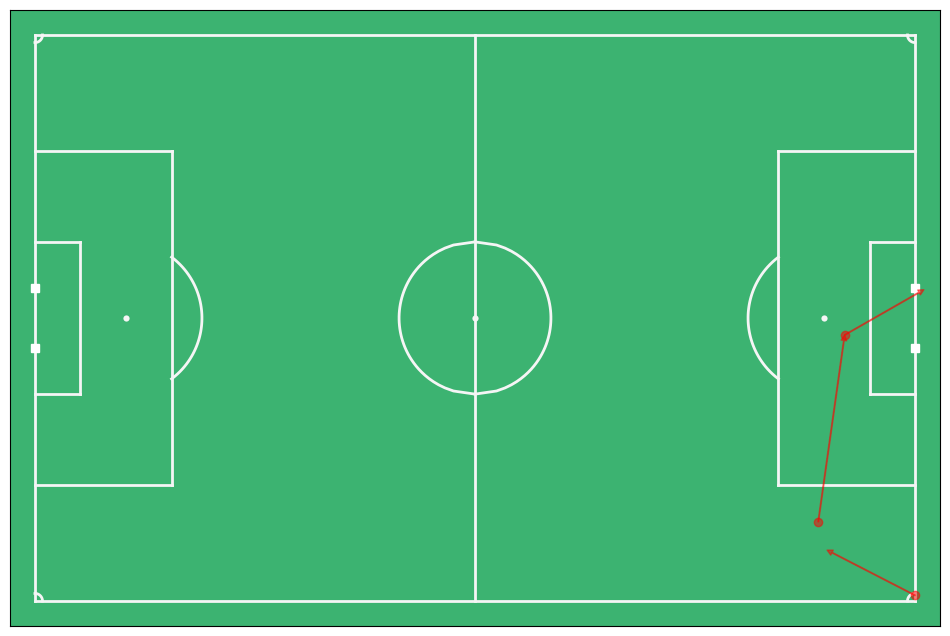

In [49]:
plot_events(event_df.loc[30:32], indicators =['Marker','Arrow'])

Looks like Player 10 assisted and player 9 scored

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

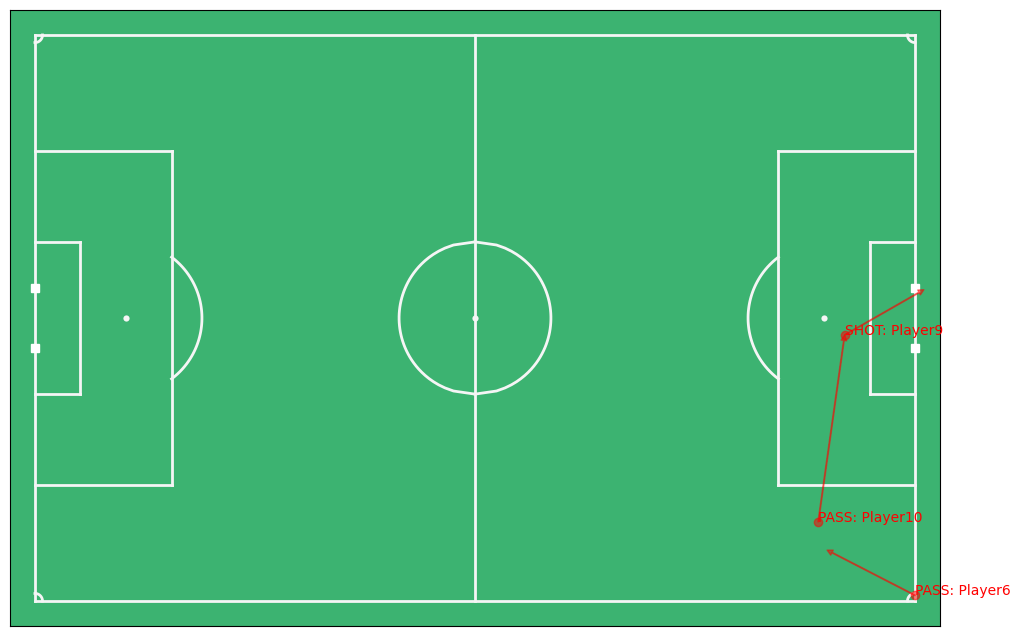

In [50]:
# which playerer were involved in making the goal. assist and scorer.
plot_events(event_df.loc[30:32], indicators =['Marker','Arrow'],annotate=True)

**Pass Length Distribution**

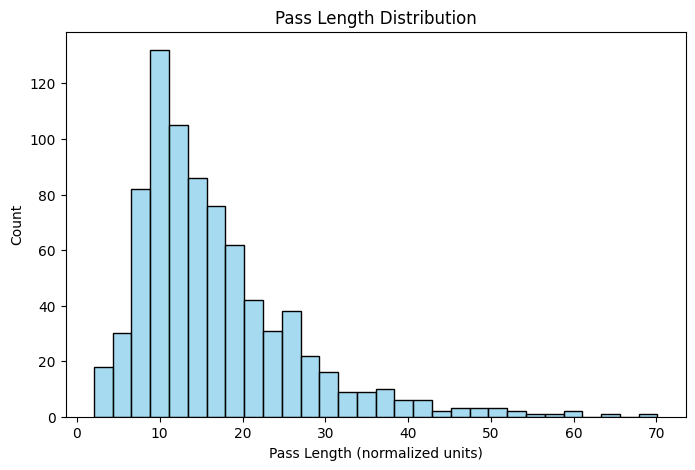

In [51]:
# Shows how far passes typically travel, helping identify the team’s style.
import matplotlib.pyplot as plt
import seaborn as sns

event_df['pass_length'] = ((event_df['End X'] - event_df['Start X'])**2 +
                           (event_df['End Y'] - event_df['Start Y'])**2)**0.5
plt.figure(figsize=(8,5))
sns.histplot(event_df[event_df['Type']=='PASS']['pass_length'], bins=30, color='skyblue')
plt.title('Pass Length Distribution')
plt.xlabel('Pass Length (normalized units)')
plt.ylabel('Count')
plt.show()

**Insight** - Shows the distribution of pass lengths to reveal whether the team favors short, controlled passes or longer, more direct plays.

**Shots**

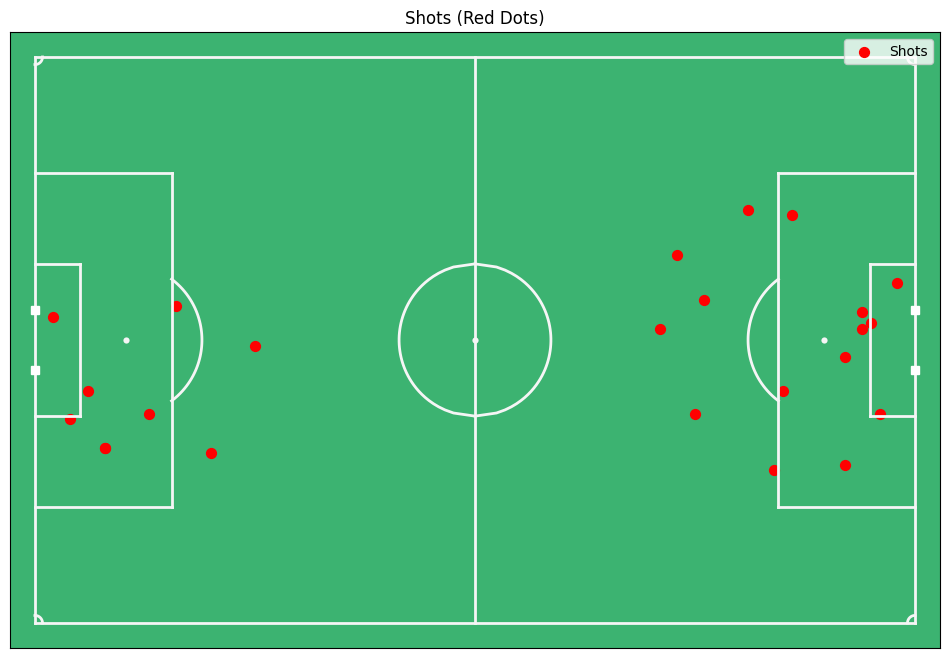

In [52]:
shots = event_df[event_df['Type'] == 'SHOT']

fig, ax = plot_pitch()
ax.scatter(shots['Start X'], shots['Start Y'],
           color='red', s=50, label='Shots')

plt.title("Shots (Red Dots)", color='black')
plt.legend(loc='upper right')
plt.show()

 **Insights** - Pinpoints where on the pitch shots are being taken, giving insight into attacking positioning and space creation patterns.

**Shot Outcome Distribution (Donut Chart)**

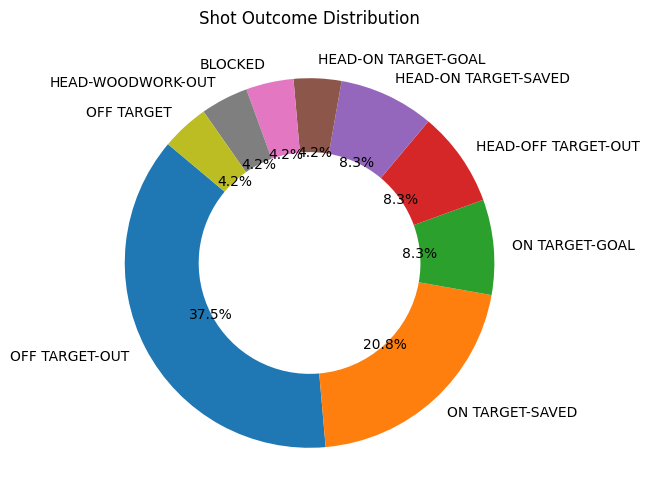

In [53]:
# Count shot outcomes based on Subtype
#We used a donut chart to clearly show the proportion of different shot outcomes (like Goal, Off Target, Blocked)
#helping us quickly understand the effectiveness and distribution of shot results in the dataset.
shot_outcomes = shots['Subtype'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(shot_outcomes, labels=shot_outcomes.index, autopct='%1.1f%%',
        startangle=140, wedgeprops=dict(width=0.4))
plt.title('Shot Outcome Distribution')
plt.show()


**Insight** - Measures finishing efficiency and the effectiveness of shot selection, which ties directly to evaluating offensive success.

**Goals vs. Non-Goals**

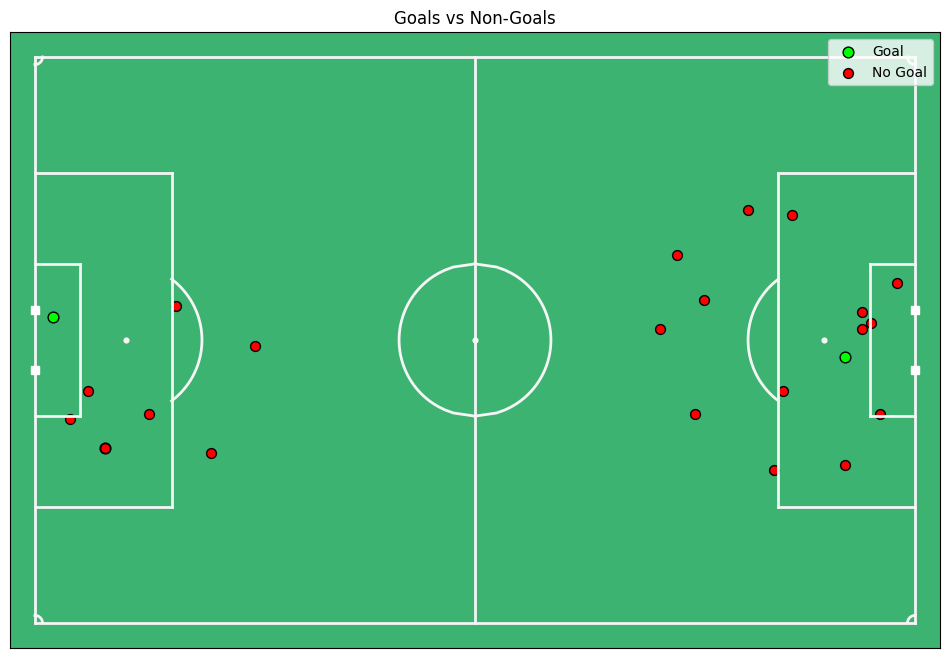

In [54]:
fig, ax = plot_pitch()

goals = shots[shots['Subtype'].str.contains('GOAL')]
nong = shots[~shots['Subtype'].str.contains('GOAL')]

ax.scatter(goals['Start X'], goals['Start Y'],
           color='lime', s=60, edgecolors='black', label='Goal')

ax.scatter(nong['Start X'], nong['Start Y'],
           color='red', s=50, edgecolors='black', label='No Goal')

plt.title("Goals vs Non-Goals", color='black')
plt.legend(loc='upper right')
plt.show()

**Insight** - Highlights where goals originate compared to missed chances, revealing high-probability scoring areas and potential areas to improve shot quality.

**Shot Density Contours**

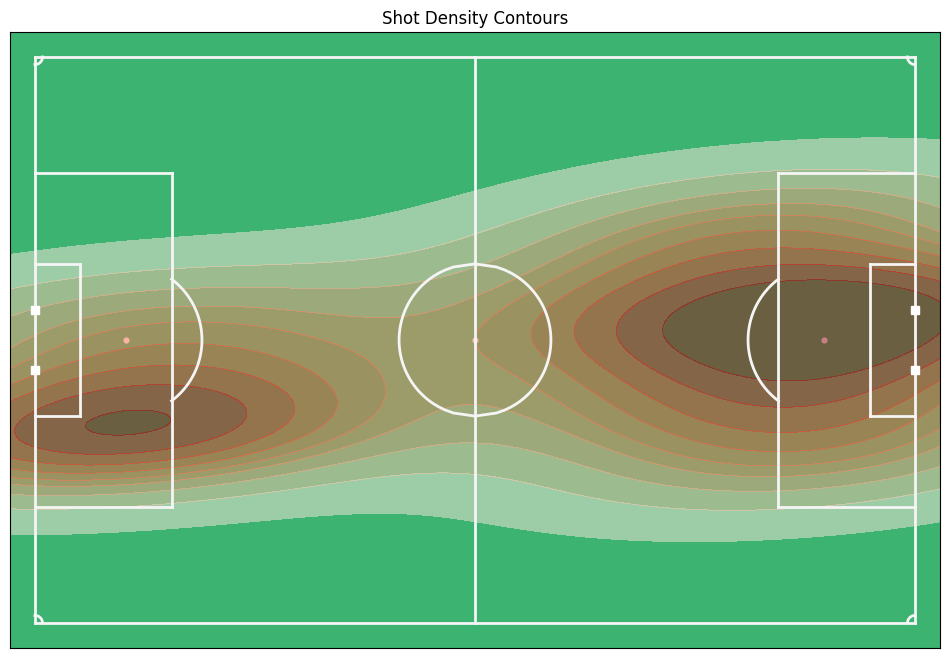

In [55]:
import seaborn as sns

fig, ax = plot_pitch()

sns.kdeplot(
    x=shots['Start X'],
    y=shots['Start Y'],
    cmap="Reds",
    fill=True,
    alpha=0.5,
    thresh=0.05,
    ax=ax
)

plt.title("Shot Density Contours", color='black')
plt.show()

**Insight** - Identifies shooting “hot zones” by showing where the team generates the highest volume of attempts, helping connect spatial tendencies with tactical decisions.

<table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>4. Preprocessed the dataset with scaling, encoding, and feature engineering
</b></font>
    </td>
  </tr>
</table>
<br>

---



In [56]:
# 1. Create distance to goal (assuming goal center is at (100, 25))
import numpy as np
event_df['distance_to_goal'] = np.sqrt((100 - event_df['Start X'])**2 + (25 - event_df['Start Y'])**2)

WHY: Distance to goal is a crucial spatial feature influencing the probability of scoring.
Shots taken closer to the goal generally have a higher chance of success.

In [57]:
# 2. Angle to goal (based on scaled goal width)
goal_width = 7.32 / 100 * 50  # scaled to pitch Y dimension
event_df['angle_to_goal'] = np.arctan2(goal_width, event_df['distance_to_goal'])

WHY: The shooting angle impacts scoring chances — wider angles (closer to the sides of the goal) typically reduce scoring probability, while central angles increase it.

In [58]:
# 3. Event speed (ensure no division by zero)
event_df['Duration'] = event_df['End Time [s]'] - event_df['Start Time [s]']
event_df['event_speed'] = np.where(event_df['Duration'] > 0,
    np.sqrt((event_df['End X'] - event_df['Start X'])**2 + (event_df['End Y'] - event_df['Start Y'])**2) / event_df['Duration'],
    0
)

WHY: Speed of the play leading to a shot or pass can influence success probability. Faster plays may catch defenses off-guard.

In [59]:
# 4. One-hot encoding for Type and Team
event_df = pd.get_dummies(event_df, columns=['Type', 'Team'], drop_first=True)

One-Hot Encoding for Event Type and Team - Preserves interpretability : lets us identify which event types and teams are associated with higher goal likelihood.

In [60]:
from sklearn.preprocessing import LabelEncoder

# 5. Label Encoding for 'From', 'To', 'Subtype'
cat_cols = ['From', 'To']
for col in cat_cols:
    event_df[col] = event_df[col].astype(str)
    le = LabelEncoder()
    event_df[col] = le.fit_transform(event_df[col])


WHY: These features may have too many categories for one-hot encoding (leading to sparse data)
so label encoding efficiently represents them as integers.

From,To- shows which players were involved in the event-it can be predictive for shot outcome (e.g. some players are more likely to shoot on target)

In [61]:
# 6. Handle any infinities or NaNs
numeric_cols = ['Start X', 'Start Y', 'End X', 'End Y', 'Duration',
                'distance_to_goal', 'angle_to_goal', 'event_speed']
event_df[numeric_cols] = event_df[numeric_cols].replace([np.inf, -np.inf], np.nan)
event_df = event_df.dropna(subset=numeric_cols)

Missing/Infinite Value Handling - Prevents model errors and biases caused by invalid data points. Dropping problematic records ensures the dataset remains clean and reliable.

In [62]:
print("Dataset shape:", event_df.shape)

Dataset shape: (1664, 25)



Feature Engineering – Insights

Distance to Goal

- Measured how far the ball is from the goal at the moment the shot is taken.
- Insight - Shots are typically more critical and more on-target if taken relatively closer to the goal.

Angle to Goal

- Measures how "open" the view to the goal is relative to the particular shot position.
- Insight - An open, central angle, is more advantageous compared to a tight angle to increase the chances of hitting the target.

Event Speed

- Measures the speed of the event which approximates the speed of the ball.

- Insight - Faster actions (e.g., quick counters) may see more shots on target.

Type & Team (One-Hot Encoded)

- Encodes event type (e.g. pass, clearance) and which team executed the event.
- Insight - Different teams or event types may produce unique shot "profiles."

From / To (Label Encoded)

- This captures which player initiated the action (`From`) and which player received the action (`To`).
- Insight - Some players will more frequently produce shots on target due to skill level/role (e.g., strikers vs defenders).

Tracking-Based Features (Player & Ball movement)

- Distance of players to the ball, distance of team centroid(s), ball acceleration, ball speed, etc.
- Insight: Spatial context (i.e. distance to players, ball speed, position on the field) is a strong influence on shot quality.

 **Conclusion**

This preprocessing pipeline extracts spatial, temporal, and categorical context from match events, encodes it into a machine-readable format, and produces a clean dataset for modeling. The features were chosen because they directly relate to our objective of predicting and understanding goal-scoring events using event and tracking data.

# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Tracking Data Preprocessing
      </b></font>
    </td>
  </tr>
</table>



In [63]:
import warnings
warnings.filterwarnings('ignore')
away = pd.read_csv("/content/data/Sample_Game_1_RawTrackingData_Away_Team.csv")
away.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Away,Unnamed: 4,Away.1,Unnamed: 6,Away.2,Unnamed: 8,Away.3,...,Away.10,Unnamed: 24,Away.11,Unnamed: 26,Away.12,Unnamed: 28,Away.13,Unnamed: 30,Away.14,Unnamed: 32
0,NaN,NaN,NaN,25,NaN,15,NaN,16,NaN,17,...,24,NaN,26,NaN,27,NaN,28,NaN,NaN,NaN
1,Period,Frame,Time [s],Player25,NaN,Player15,NaN,Player16,NaN,Player17,...,Player24,NaN,Player26,NaN,Player27,NaN,Player28,NaN,Ball,NaN
2,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


In [64]:
home = pd.read_csv("/content/data/Sample_Game_1_RawTrackingData_Home_Team.csv")
home.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Home,Unnamed: 4,Home.1,Unnamed: 6,Home.2,Unnamed: 8,Home.3,...,Home.10,Unnamed: 24,Home.11,Unnamed: 26,Home.12,Unnamed: 28,Home.13,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,NaN,NaN,NaN,11,NaN,1,NaN,2,NaN,3,...,10,NaN,12,NaN,13,NaN,14,NaN,NaN,NaN
1,Period,Frame,Time [s],Player11,NaN,Player1,NaN,Player2,NaN,Player3,...,Player10,NaN,Player12,NaN,Player13,NaN,Player14,NaN,Ball,NaN
2,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


**clean_tracking_data**:
*   This function takes raw tracking data from a CSV file (e.g., player & ball
positions during a match) and cleans it so it has:

Correct column names

* Correct column names
* Properly labeled player coordinates
* A consistent structure for further analysis
* It takes two inputs:
* file_path → The CSV file’s location.
* team_label → A label for the team ("Home" or "Away").

**1. Load and skip the first row**
* Skips the first row because it only contains the team name, not useful as data.

**2. Set the real column headers**
* The first row of df now contains the actual column names.
* Assigns the extracted header row to df.columns.

**3. Identify different column groups**
* base_cols - Metadata for each frame:
* Period - Half of the game (1 or 2)
* Frame - Frame number in tracking
* Time [s] - Timestamp in seconds
* player_cols - Player tracking columns (usually X and Y positions for each player).
* ball_cols - Last two columns, assumed to be ball X and Y coordinates.

**4. Rename player columns consistently**
* Loops through player columns two at a time (since each player has X and Y columns).
* Cleans the player number from the column name.
* Builds a list like:
Player1_x, Player1_y, Player2_x, Player2_y, ...

**5. Finalize column names & add team label**
* Combines:
* Base columns (Period, Frame, Time [s])
* Player position columns
* Ball position columns
* Adds a new column "Team" with the given label (so you can later merge Home & Away data).

**6. Convert columns to numeric where possible**
* Tries to convert each column to a number.
* If a column contains non-numeric data (like "unk1_x"), it leaves it as is.

**7. Return cleaned data**

In [65]:
def clean_tracking_data(file_path, team_label):
    df = pd.read_csv(file_path, skiprows=[0])

    # Use next row as header
    new_header = df.iloc[0].fillna('')
    df = df.drop(0).reset_index(drop=True)
    df.columns = new_header

    # Identifying the columns
    base_cols = ['Period', 'Frame', 'Time [s]']
    player_cols = df.columns[3:-2]  # players between base cols and ball
    ball_cols = ['Ball_x', 'Ball_y']

    # Renaming player columns
    player_labels = []
    for i in range(0, len(player_cols), 2):
        x_col = player_cols[i]
        y_col = player_cols[i + 1]

        # Extracting player number from column name
        player_num = str(x_col).strip().replace("Player", "").replace(" ", "")
        if not player_num.isdigit():
            player_num = f"unk{i//2 + 1}"  # fallback if no number
        player_labels.extend([f"Player{player_num}_x", f"Player{player_num}_y"])

    # Final column names
    df.columns = base_cols + player_labels + ball_cols
    df['Team'] = team_label

    # 2. Convert numeric columns where possible
    df = df.apply(pd.to_numeric, errors='ignore')
    return df


In [66]:
home_df = clean_tracking_data('/content/data/Sample_Game_1_RawTrackingData_Home_Team.csv', 'Home')
home_df.head()

,Period,Frame,Time [s],Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player10_y,Player12_x,Player12_y,Player13_x,Player13_y,Player14_x,Player14_y,Ball_x,Ball_y,Team
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709,Home
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656,Home
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556,Home
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231,Home
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570,Home


In [67]:
away_df = clean_tracking_data('/content/data/Sample_Game_1_RawTrackingData_Away_Team.csv', 'Away')
away_df.head()

,Period,Frame,Time [s],Player25_x,Player25_y,Player15_x,Player15_y,Player16_x,Player16_y,Player17_x,...,Player24_y,Player26_x,Player26_y,Player27_x,Player27_y,Player28_x,Player28_y,Ball_x,Ball_y,Team
0,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709,Away
1,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656,Away
2,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556,Away
3,1,4,0.16,0.90377,0.47463,0.58351,0.20868,0.67640,0.46762,0.67279,...,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231,Away
4,1,5,0.20,0.90324,0.47464,0.58291,0.21039,0.67599,0.46769,0.67253,...,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570,Away


**1. Copy the DataFrame**
* This prevents accidental modification of the original DataFrame

**2. Identify data columns**
* Some columns are metadata (Period, Frame, Time [s], Team) — not actual player/ball tracking numbers.
* df.columns.difference(exclude columns) gets all other columns (e.g., Player1_x, Player1_y, Ball_x, Ball_y).

**3. Create a "flag" column**
* Result:
* 1 means the row has at least one missing value.
* 0 means the row has no missing values.

**4. Count frequency of each flag value**
* Example:
* If there are 100 rows with flag 0, then all those rows get flag_freq = 100.
* If there are 20 rows with flag 1, then all those rows get flag_freq = 20.

**5. Create a "Total" summary row**
* Creates a new row with None in every column.
* Puts 'Total' under Team.
* flag_freq is also set to that number (so here it’s acting as “count of flagged rows”).

**6. Append total row**
* Adds the summary row at the bottom of the DataFrame.


In [68]:
import pandas as pd

def add_flag_and_freq_with_total(df):
    df = df.copy()

    # 1: Identify columns to evaluate (exclude metadata if present)
    exclude_cols = ['Period', 'Frame', 'Time [s]', 'Team']
    data_cols = df.columns.difference(exclude_cols)

    # 2: Add flag where any NaN exists in row
    df['flag'] = df[data_cols].isnull().any(axis=1).astype(int)

    # 3: Count frequency of each flag value
    flag_counts = df['flag'].value_counts().to_dict()
    df['flag_freq'] = df['flag'].map(flag_counts)

    # 4: Add Total Row
    total_row = pd.DataFrame({col: [None] for col in df.columns})
    total_row.at[0, 'Team'] = 'Total'
    total_row.at[0, 'flag'] = df['flag'].sum()
    total_row.at[0, 'flag_freq'] = df['flag'].sum()  # Same as count of flagged rows

    # 5: Append to the original dataframe
    df = pd.concat([df, total_row], ignore_index=True)

    return df

# Apply to both
home_df = add_flag_and_freq_with_total(home_df)
away_df = add_flag_and_freq_with_total(away_df)

**In summary:**
This function:
1. Finds missing values in any data column per row.
2. Flags rows with missing values (flag = 1).
3. Adds a column showing how many rows share that flag value (flag_freq).
4. Appends a total row summarizing the total count of flagged rows.
--------------------------------------------------------------------

**Insight**
1. First print: shows how many missing values each column has.
2. Second print: shows what percentage of rows are missing in each column.
3. Both exclude the “Total” row, since that would artificially increase missing counts

In [69]:
# HOME tracking data
print("\n Missing value COUNT (Home):")
print(home_df.loc[~home_df['Team'].astype(str).str.contains('Total', na=False)].isnull().sum())

print("\n Missing value PERCENTAGE (Home):")
missing_percent_home = home_df.loc[~home_df['Team'].astype(str).str.contains('Total', na=False)].isnull().mean() * 100
print(missing_percent_home)


 Missing value COUNT (Home):
Period             0
Frame              0
Time [s]           0
Player11_x         0
Player11_y         0
Player1_x      98300
Player1_y      98300
Player2_x          0
Player2_y          0
Player3_x          0
Player3_y          0
Player4_x          0
Player4_y          0
Player5_x          0
Player5_y          0
Player6_x      34157
Player6_y      34157
Player7_x          0
Player7_y          0
Player8_x          0
Player8_y          0
Player9_x          0
Player9_y          0
Player10_x     23614
Player10_y     23614
Player12_x     46705
Player12_y     46705
Player13_x    110848
Player13_y    110848
Player14_x    121391
Player14_y    121391
Ball_x         56755
Ball_y         56755
Team               0
flag               0
flag_freq          0
dtype: int64

 Missing value PERCENTAGE (Home):
Period         0.000000
Frame          0.000000
Time [s]       0.000000
Player11_x     0.000000
Player11_y     0.000000
Player1_x     67.790298
Player1_y     67.79029

This AWAY block is exactly the same logic as the HOME. The only difference is that it’s applied to away_df instead of home_df.

In [70]:
# AWAY tracking data
print("\n Missing value COUNT (Away):")
print(away_df.loc[~away_df['Team'].astype(str).str.contains('Total', na=False)].isnull().sum())

print("\n Missing value PERCENTAGE (Away):")
missing_percent_away = away_df.loc[~away_df['Team'].astype(str).str.contains('Total', na=False)].isnull().mean() * 100
print(missing_percent_away)


 Missing value COUNT (Away):
Period             0
Frame              0
Time [s]           0
Player25_x         0
Player25_y         0
Player15_x         0
Player15_y         0
Player16_x         0
Player16_y         0
Player17_x         0
Player17_y         0
Player18_x         0
Player18_y         0
Player19_x     25625
Player19_y     25625
Player20_x         0
Player20_y         0
Player21_x         0
Player21_y         0
Player22_x     38137
Player22_y     38137
Player23_x         0
Player23_y         0
Player24_x     38407
Player24_y     38407
Player26_x    106598
Player26_y    106598
Player27_x    106868
Player27_y    106868
Player28_x    119380
Player28_y    119380
Ball_x         56755
Ball_y         56755
Team               0
flag               0
flag_freq          0
dtype: int64

 Missing value PERCENTAGE (Away):
Period         0.000000
Frame          0.000000
Time [s]       0.000000
Player25_x     0.000000
Player25_y     0.000000
Player15_x     0.000000
Player15_y     0.00000


<table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>2. Performed data cleaning using Python
</b></font>
    </td>
  </tr>
</table>
<br>




This list contains the exact column names you want to remove from the DataFrame.
Each player has two columns:


*  PlayerN_x
*  PlayerN_y


* Here we are removing position data for players 1, 6, 10, 12, 13, and 14.

In [71]:
cols_to_drop_home = [
    'Player1_x', 'Player1_y',
    'Player6_x', 'Player6_y',
    'Player10_x', 'Player10_y',
    'Player12_x', 'Player12_y',
    'Player13_x', 'Player13_y',
    'Player14_x', 'Player14_y'
]

home_df = home_df.drop(columns=cols_to_drop_home)

This is doing the same type of operation you saw for home_df, but for the away team’s tracking data (away_df).



In [72]:
cols_to_drop_away = [
    'Player19_x', 'Player19_y',
    'Player22_x', 'Player22_y',
    'Player24_x', 'Player24_y',
    'Player26_x', 'Player26_y',
    'Player27_x', 'Player27_y',
    'Player28_x', 'Player28_y'
]

away_df = away_df.drop(columns=cols_to_drop_away)

**1. Interpolating missing ball positions**
* Looks at the ball’s x and y positions.
* If there are missing (NaN) values, it fills them in by assuming the ball moved in a straight line between known positions (linear interpolation).
* limit_direction='both' means missing values at the start or end will also be filled using the nearest available value.
* Why? Tracking systems sometimes fail to record a ball position for a frame; interpolating keeps the movement smooth.

**2. Rescaling normalized coordinates to meters**
* Tracking data often stores positions normalized between 0 and 1.
* 0 = left or top edge
* 1 = right or bottom edge
* A standard football pitch here is 106 meters long and 68 meters wide.
* This step multiplies:
* All X positions by 106 (meters)
* All Y positions by 68 (meters)
* Why? For physical analysis (speed, distance covered), you need real-world units.

**3. Clipping values to the field bounds**
* Makes sure positions don’t go outside the pitch:
* X between 0 and 106
* Y between 0 and 68
* Why? Even after interpolation, small sensor errors might produce unrealistic coordinates (e.g., ball outside the pitch).



**This function takes raw tracking data and outputs:**
* No missing ball positions
* Coordinates in meters instead of normalized values
* All positions inside the pitch

In [73]:
def preprocess_positions(df):
    FIELD_LENGTH = 106.0  # meters
    FIELD_WIDTH = 68.0    # meters

    # 1. Interpolating missing ball positions
    df[['Ball_x', 'Ball_y']] = df[['Ball_x', 'Ball_y']].interpolate(
        method='linear', limit_direction='both'
    )

    # 2. Rescaling normalized coordinates to meters
    for col in df.columns:
        if '_x' in col:
            df[col] *= FIELD_LENGTH
        elif '_y' in col:
            df[col] *= FIELD_WIDTH

    # 3. Clip the values to field bounds
    for col in df.columns:
        if '_x' in col:
            df[col] = df[col].clip(0, FIELD_LENGTH)
        elif '_y' in col:
            df[col] = df[col].clip(0, FIELD_WIDTH)

    return df

In [74]:
# Apply to home data
print(" Preprocessing Home Team Data")
home_df = preprocess_positions(home_df)

# Apply to away data
print("\n Preprocessing Away Team Data")
away_df = preprocess_positions(away_df)

 Preprocessing Home Team Data

 Preprocessing Away Team Data







 <table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>3. Conducted EDA with summary statistics and visualizations
</b></font>
    </td>
  </tr>
</table>




In [75]:
away_df.head()

,Period,Frame,Time [s],Player25_x,Player25_y,Player15_x,Player15_y,Player16_x,Player16_y,Player17_x,...,Player20_y,Player21_x,Player21_y,Player23_x,Player23_y,Ball_x,Ball_y,Team,flag,flag_freq
0,1,1,0.04,95.93954,32.27416,61.89658,14.13992,71.71748,31.76280,71.34860,...,46.08700,58.55758,29.42292,46.31458,3.40136,48.20032,26.32212,Away,1,145006
1,1,2,0.08,95.92364,32.27416,61.89658,14.13992,71.71748,31.76280,71.34860,...,46.08700,58.55758,29.42292,46.31458,3.40136,52.62370,27.64608,Away,1,145006
2,1,3,0.12,95.86004,32.27484,61.89658,14.13992,71.71748,31.76280,71.34860,...,46.08700,58.55758,29.42292,46.31458,3.40136,56.93896,28.93808,Away,1,145006
3,1,4,0.16,95.79962,32.27484,61.85206,14.19024,71.69840,31.79816,71.31574,...,46.08768,58.55016,29.45284,46.26264,3.42584,58.66676,28.71708,Away,1,145006
4,1,5,0.20,95.74344,32.27552,61.78846,14.30652,71.65494,31.80292,71.28818,...,46.09788,58.51412,29.45148,46.19480,3.38436,58.84272,27.58760,Away,1,145006


For the away team tracking data, exclude rows where the Team column contains the word 'Total', then count how many missing values each column has.

In [76]:
print(away_df.loc[~away_df['Team'].astype(str).str.contains('Total', na=False)].isnull().sum())

Period        0
Frame         0
Time [s]      0
Player25_x    0
Player25_y    0
Player15_x    0
Player15_y    0
Player16_x    0
Player16_y    0
Player17_x    0
Player17_y    0
Player18_x    0
Player18_y    0
Player20_x    0
Player20_y    0
Player21_x    0
Player21_y    0
Player23_x    0
Player23_y    0
Ball_x        0
Ball_y        0
Team          0
flag          0
flag_freq     0
dtype: int64


In [77]:
away_df.shape

(145007, 24)

In [78]:
away_df.columns

Index(['Period', 'Frame', 'Time [s]', 'Player25_x', 'Player25_y', 'Player15_x',
       'Player15_y', 'Player16_x', 'Player16_y', 'Player17_x', 'Player17_y',
       'Player18_x', 'Player18_y', 'Player20_x', 'Player20_y', 'Player21_x',
       'Player21_y', 'Player23_x', 'Player23_y', 'Ball_x', 'Ball_y', 'Team',
       'flag', 'flag_freq'],
      dtype='object')

In [79]:
away_df.describe()

,Time [s],Player25_x,Player25_y,Player15_x,Player15_y,Player16_x,Player16_y,Player17_x,Player17_y,Player18_x,Player18_y,Player20_x,Player20_y,Player21_x,Player21_y,Player23_x,Player23_y,Ball_x,Ball_y
count,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145006.000000,145007.000000,145007.000000
mean,2900.140000,52.844216,33.965446,56.192832,35.269503,55.785157,35.912281,59.987572,48.478258,58.361026,29.772957,53.663913,31.023439,52.702482,37.859938,56.658495,34.918955,58.478846,35.060215
std,1674.390836,41.923635,4.689450,24.476223,13.253959,23.384464,8.411099,23.116225,13.357946,20.735301,16.871071,22.391518,12.600704,20.662973,14.352571,21.274161,13.573141,29.785435,19.598978
min,0.040000,0.000000,12.455560,0.000000,0.000000,0.000000,7.380720,0.000000,0.603160,3.136540,0.000000,0.000000,0.114240,0.000000,0.161160,0.000000,0.000000,0.000000,0.000000
25%,1450.090000,12.346085,31.904240,40.247140,25.623080,40.293780,30.772720,45.185680,41.034600,45.359520,15.951440,40.099800,21.945130,40.158100,28.007160,41.102825,24.923360,38.311580,18.487500
50%,2900.140000,30.049940,33.216640,55.024600,36.520080,54.005940,35.647980,59.786650,51.272340,57.891900,27.213600,52.086280,30.123320,53.475940,36.682940,57.250600,34.821440,61.117480,35.172320
75%,4350.190000,94.991900,35.185920,72.973580,45.317240,72.894080,40.468670,77.218880,58.338560,73.738900,44.169230,66.336920,37.911190,65.729540,48.789150,73.376380,44.655430,78.680090,50.209160
max,5800.240000,106.000000,67.147280,106.000000,68.000000,105.209240,68.000000,106.000000,68.000000,106.000000,68.000000,106.000000,67.663400,104.571120,68.000000,106.000000,68.000000,106.000000,68.000000


In [80]:
missing_percent_away = away_df.loc[~away_df['Team'].astype(str).str.contains('Total', na=False)].isnull().mean() * 100
print(missing_percent_away.sort_values(ascending=False))

Period        0.0
Frame         0.0
Time [s]      0.0
Player25_x    0.0
Player25_y    0.0
Player15_x    0.0
Player15_y    0.0
Player16_x    0.0
Player16_y    0.0
Player17_x    0.0
Player17_y    0.0
Player18_x    0.0
Player18_y    0.0
Player20_x    0.0
Player20_y    0.0
Player21_x    0.0
Player21_y    0.0
Player23_x    0.0
Player23_y    0.0
Ball_x        0.0
Ball_y        0.0
Team          0.0
flag          0.0
flag_freq     0.0
dtype: float64


In [81]:
home_df.head()

,Period,Frame,Time [s],Player11_x,Player11_y,Player2_x,Player2_y,Player3_x,Player3_y,Player4_x,...,Player7_y,Player8_x,Player8_y,Player9_x,Player9_y,Ball_x,Ball_y,Team,flag,flag_freq
0,1,1,0.04,0.08692,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,22.13400,48.11128,14.39832,55.85882,25.82640,48.20032,26.32212,Home,1,145006
1,1,2,0.08,0.10176,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,22.13400,48.11128,14.39832,55.85882,25.82640,52.62370,27.64608,Home,1,145006
2,1,3,0.12,0.12084,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,22.13400,48.11128,14.39832,55.85882,25.82640,56.93896,28.93808,Home,1,145006
3,1,4,0.16,0.12826,32.80184,35.70822,33.31184,32.80064,24.17672,34.07052,...,22.14488,48.10174,14.31604,55.89486,25.84680,58.66676,28.71708,Home,1,145006
4,1,5,0.20,0.13674,32.80184,35.68384,33.33224,32.80488,24.15904,34.06416,...,22.05036,48.09856,14.24600,55.90122,25.83388,58.84272,27.58760,Home,1,145006


In [82]:
print(home_df.loc[~home_df['Team'].astype(str).str.contains('Total', na=False)].isnull().sum())

Period        0
Frame         0
Time [s]      0
Player11_x    0
Player11_y    0
Player2_x     0
Player2_y     0
Player3_x     0
Player3_y     0
Player4_x     0
Player4_y     0
Player5_x     0
Player5_y     0
Player7_x     0
Player7_y     0
Player8_x     0
Player8_y     0
Player9_x     0
Player9_y     0
Ball_x        0
Ball_y        0
Team          0
flag          0
flag_freq     0
dtype: int64


In [83]:
home_df.shape

(145007, 24)

In [84]:
home_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145007 entries, 0 to 145006
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Period      145006 non-null  object 
 1   Frame       145006 non-null  object 
 2   Time [s]    145006 non-null  float64
 3   Player11_x  145006 non-null  float64
 4   Player11_y  145006 non-null  float64
 5   Player2_x   145006 non-null  float64
 6   Player2_y   145006 non-null  float64
 7   Player3_x   145006 non-null  float64
 8   Player3_y   145006 non-null  float64
 9   Player4_x   145006 non-null  float64
 10  Player4_y   145006 non-null  float64
 11  Player5_x   145006 non-null  float64
 12  Player5_y   145006 non-null  float64
 13  Player7_x   145006 non-null  float64
 14  Player7_y   145006 non-null  float64
 15  Player8_x   145006 non-null  float64
 16  Player8_y   145006 non-null  float64
 17  Player9_x   145006 non-null  float64
 18  Player9_y   145006 non-null  float64
 19  Ba

In [85]:
home_df.columns

Index(['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player2_x',
       'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y',
       'Player5_x', 'Player5_y', 'Player7_x', 'Player7_y', 'Player8_x',
       'Player8_y', 'Player9_x', 'Player9_y', 'Ball_x', 'Ball_y', 'Team',
       'flag', 'flag_freq'],
      dtype='object')

In [86]:
# Recalculate flag after cleaning
away_df['flag'] = away_df.isnull().any(axis=1).astype(int)

# Calculate flag percentage
away_flag_percent = away_df['flag'].sum() / len(away_df) * 100
print(f"Away flag percentage after cleaning: {away_flag_percent:.2f}%")

Away flag percentage after cleaning: 0.00%


In [87]:
# Recalculate flag after cleaning
home_df['flag'] = home_df.isnull().any(axis=1).astype(int)

# Calculate flag percentage
home_flag_percent = home_df['flag'].sum() / len(home_df) * 100
print(f"Home flag percentage after cleaning: {home_flag_percent:.2f}%")

Home flag percentage after cleaning: 0.00%


In [88]:
home_df.to_csv('/content/home_cleaned_with_flags.csv', index=False)
away_df.to_csv('/content/away_cleaned_with_flags.csv', index=False)

In [89]:
print("Saved home and away data with flag and frequency columns.")

Saved home and away data with flag and frequency columns.


In [90]:
# Drop any flag-related columns if they exist
home_clean = home_df.drop(
    columns=[col for col in ['flag', 'flag_percent', 'flag_x', 'flag_y', 'flag_freq', 'flag_freq_x', 'flag_freq_y']
             if col in home_df.columns],
    errors='ignore'
).iloc[:-1].reset_index(drop=True)

away_clean = away_df.drop(
    columns=[col for col in ['flag', 'flag_percent', 'flag_x', 'flag_y', 'flag_freq', 'flag_freq_x', 'flag_freq_y']
             if col in away_df.columns],
    errors='ignore'
).iloc[:-1].reset_index(drop=True)

In [91]:
home_clean.to_csv('/content/home_cleaned.csv', index=False)
away_clean.to_csv('/content/away_cleaned.csv', index=False)

**1. Merge the two cleaned datasets**

**2. Sort by period and frame**

**3. Save to CSV**

Result: A clean, combined, time-ordered tracking dataset ready for sharing or further analysis.



In [92]:
merged_df = pd.merge(home_clean, away_clean, on=["Period", "Frame", "Time [s]"], how="inner")
merged_df.head(10)

,Period,Frame,Time [s],Player11_x,Player11_y,Player2_x,Player2_y,Player3_x,Player3_y,Player4_x,...,Player18_y,Player20_x,Player20_y,Player21_x,Player21_y,Player23_x,Player23_y,Ball_x_y,Ball_y_y,Team_y
0,1,1,0.04,0.08692,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,41.83700,59.31760,46.08700,58.55758,29.42292,46.31458,3.40136,48.20032,26.32212,Away
1,1,2,0.08,0.10176,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,41.83700,59.31760,46.08700,58.55758,29.42292,46.31458,3.40136,52.62370,27.64608,Away
2,1,3,0.12,0.12084,32.80184,35.72306,33.22684,32.78262,24.15972,34.06522,...,41.83700,59.31760,46.08700,58.55758,29.42292,46.31458,3.40136,56.93896,28.93808,Away
3,1,4,0.16,0.12826,32.80184,35.70822,33.31184,32.80064,24.17672,34.07052,...,41.82340,59.33244,46.08768,58.55016,29.45284,46.26264,3.42584,58.66676,28.71708,Away
4,1,5,0.20,0.13674,32.80184,35.68384,33.33224,32.80488,24.15904,34.06416,...,41.80028,59.35152,46.09788,58.51412,29.45148,46.19480,3.38436,58.84272,27.58760,Away
5,1,6,0.24,0.14840,32.80184,35.65522,33.29688,32.83668,24.12572,34.08854,...,41.69012,59.37802,46.01968,58.46642,29.41476,46.11424,3.32112,59.01762,26.45812,Away
6,1,7,0.28,0.14840,32.80184,35.64144,33.26492,32.87590,24.09852,34.12988,...,41.55548,59.41194,45.89388,58.40070,29.37600,46.02838,3.26740,59.19252,25.32864,Away
7,1,8,0.32,0.14840,32.80184,35.62448,33.23092,32.91300,24.05364,34.17758,...,41.43444,59.44904,45.76808,58.33604,29.30256,45.94782,3.16676,59.36424,24.22772,Away
8,1,9,0.36,0.12720,32.77124,35.60858,33.19080,32.95434,24.02100,34.21892,...,41.30864,59.49038,45.63072,58.25866,29.24204,45.86938,3.11304,59.54338,23.06968,Away
9,1,10,0.40,0.10600,32.73996,35.59586,33.15408,33.00098,23.98020,34.25072,...,41.19168,59.53278,45.47636,58.17280,29.16520,45.79094,3.01512,59.71828,21.94020,Away


In [93]:
merged_df.columns

Index(['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player2_x',
       'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y',
       'Player5_x', 'Player5_y', 'Player7_x', 'Player7_y', 'Player8_x',
       'Player8_y', 'Player9_x', 'Player9_y', 'Ball_x_x', 'Ball_y_x', 'Team_x',
       'Player25_x', 'Player25_y', 'Player15_x', 'Player15_y', 'Player16_x',
       'Player16_y', 'Player17_x', 'Player17_y', 'Player18_x', 'Player18_y',
       'Player20_x', 'Player20_y', 'Player21_x', 'Player21_y', 'Player23_x',
       'Player23_y', 'Ball_x_y', 'Ball_y_y', 'Team_y'],
      dtype='object')

In [94]:
# Saving file without flags (for visualization, modeling, sharing)
merged_df.to_csv('/content/tracking_df.csv', index=False)

In [95]:
# Merge ball position columns into single ones
merged_df['Ball_x'] = merged_df['Ball_x_x']
merged_df['Ball_y'] = merged_df['Ball_y_x']

# If Team_x and Team_y are identical
if (merged_df['Team_x'] == merged_df['Team_y']).all():
    merged_df['Team'] = merged_df['Team_x']
    merged_df = merged_df.drop(columns=['Team_x', 'Team_y'])
else:
    print("Team_x and Team_y is for Home and Away")

# Drop the duplicate ball columns
merged_df = merged_df.drop(columns=['Ball_x_x', 'Ball_y_x', 'Ball_x_y', 'Ball_y_y'])

Team_x and Team_y is for Home and Away


In [96]:
merged_df = merged_df.rename(columns={
    'Team_x': 'HomeTeam',
    'Team_y': 'AwayTeam'
})

In [97]:
merged_df.tail(10)

,Period,Frame,Time [s],Player11_x,Player11_y,Player2_x,Player2_y,Player3_x,Player3_y,Player4_x,...,Player18_y,Player20_x,Player20_y,Player21_x,Player21_y,Player23_x,Player23_y,AwayTeam,Ball_x,Ball_y
144996,2,144997,5799.88,96.25224,31.06920,36.34952,43.95044,33.08578,45.88028,12.11368,...,52.62588,15.57564,38.23776,10.89574,55.84296,31.33148,33.42132,Away,3.24148,67.81368
144997,2,144998,5799.92,96.21514,31.01480,36.32090,43.94568,33.09002,45.89252,12.11368,...,52.62588,15.62334,38.22620,10.90846,55.82596,31.30710,33.37032,Away,3.24148,67.81368
144998,2,144999,5799.96,96.17274,30.96992,36.29334,43.93888,33.09850,45.90068,12.11368,...,52.62588,15.67316,38.23504,10.92118,55.80692,31.28272,33.32476,Away,3.24148,67.81368
144999,2,145000,5800.00,96.12504,30.93660,36.26790,43.93072,33.10486,45.90544,12.11368,...,52.62588,15.71768,38.23232,10.93178,55.78584,31.25516,33.28668,Away,3.24148,67.81368
145000,2,145001,5800.04,96.08794,30.89104,36.23504,43.92256,33.10380,45.90476,12.11368,...,52.62588,15.77068,38.24184,10.94450,55.77088,31.22230,33.26016,Away,3.24148,67.81368
145001,2,145002,5800.08,96.05084,30.84140,36.20642,43.92664,33.10168,45.90884,12.11368,...,52.62588,15.80778,38.23640,10.93602,55.74368,31.18096,33.23432,Away,3.24148,67.81368
145002,2,145003,5800.12,95.98300,30.84140,36.17462,43.91644,33.10380,45.91972,12.11368,...,52.62588,15.83322,38.22824,10.93814,55.73280,31.13538,33.20848,Away,3.24148,67.81368
145003,2,145004,5800.16,95.92152,30.84140,36.13434,43.90692,33.08684,45.90068,12.11368,...,52.62588,15.82156,38.21872,10.90210,55.72192,31.09086,33.18400,Away,3.24148,67.81368
145004,2,145005,5800.20,95.88336,30.84208,36.09936,43.89536,33.04126,45.87824,12.11368,...,52.62588,15.74842,38.12624,10.84486,55.72192,31.02832,33.17652,Away,3.24148,67.81368
145005,2,145006,5800.24,95.88336,30.84208,36.03576,43.88992,32.98932,45.92176,12.11368,...,52.62588,15.73676,38.09156,10.79822,55.74640,31.02302,33.25404,Away,3.24148,67.81368


In [98]:
# Count null values per column
null_counts = merged_df.isna().sum()
print("Null values per column:")
print(null_counts)

Null values per column:
Period        0
Frame         0
Time [s]      0
Player11_x    0
Player11_y    0
Player2_x     0
Player2_y     0
Player3_x     0
Player3_y     0
Player4_x     0
Player4_y     0
Player5_x     0
Player5_y     0
Player7_x     0
Player7_y     0
Player8_x     0
Player8_y     0
Player9_x     0
Player9_y     0
HomeTeam      0
Player25_x    0
Player25_y    0
Player15_x    0
Player15_y    0
Player16_x    0
Player16_y    0
Player17_x    0
Player17_y    0
Player18_x    0
Player18_y    0
Player20_x    0
Player20_y    0
Player21_x    0
Player21_y    0
Player23_x    0
Player23_y    0
AwayTeam      0
Ball_x        0
Ball_y        0
dtype: int64


In [99]:
# Total number of null values in the whole DataFrame
total_nulls = merged_df.isna().sum().sum()
print(f"\nTotal null values in dataset: {total_nulls}")


Total null values in dataset: 0


In [100]:
duplicates_by_frame = merged_df[merged_df.duplicated(subset=["Frame"])]
duplicates_by_keys = merged_df[merged_df.duplicated(subset=["Period", "Frame", "Time [s]"])]

**1. Create the figure and axes**
* Creates a blank plotting area.
* figsize=(12, 8) → sets the size in inches (wide rectangle for a pitch).

**2. Set the background color**
* Makes both:
* The plot area (ax) green (pitch area).
* The surrounding figure background (fig) green too.

**3. Draw the pitch outline**
* Coordinates define the rectangle outline:
(0,0) → (0,50) → (100,50) → (100,0) → (0,0).
* color="white" → white lines like real pitch markings.
* Pitch here is 100 units long and 50 units wide (scaled model)

**4. Draw the center line**
* A vertical line splitting the pitch at x=50.

**5. Draw the left penalty area**
* Creates the penalty box rectangle on the left side.

**6. Draw the right penalty area**
* Same as above, but mirrored for the right side.

**7. Draw the center circle**
* Creates a circle at the center (50, 25) with radius 8.5.
* fill=False → only outline, no fill.

**8. Adjust axes**
* Fixes the pitch boundaries.
* Removes axis numbers and ticks (axis('off')).

In [101]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def draw_pitch():
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set both axis and figure background to green
    ax.set_facecolor('green')
    fig.patch.set_facecolor('green')

    # Pitch outline
    ax.plot([0, 0, 100, 100, 0], [0, 50, 50, 0, 0], color="white")

    # Center line
    ax.plot([50, 50], [0, 50], color="white")

    # Left penalty area
    ax.plot([0, 16.5], [10, 10], color="white")
    ax.plot([0, 16.5], [40, 40], color="white")
    ax.plot([16.5, 16.5], [10, 40], color="white")

    # Right penalty area
    ax.plot([100, 83.5], [10, 10], color="white")
    ax.plot([100, 83.5], [40, 40], color="white")
    ax.plot([83.5, 83.5], [10, 40], color="white")

    # Center circle
    center_circle = Circle((50, 25), 8.5, color="white", fill=False)
    ax.add_patch(center_circle)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)
    ax.axis('off')
    return fig, ax

**1. Create the figure**
* Sets the figure size to 12 inches wide × 6 inches tall.
* A rectangular format works well for football pitches.

**2. Draw the ball’s path (continuous line)**
* Uses Ball_x (horizontal position) and Ball_y (vertical position) from merged_df to plot the trajectory.
* color='white' → white path for visibility against the green pitch.
* linewidth=1 → thin but visible line.

**3. Add points for each ball position**
* Plots dots at every recorded ball position.
* c='red' → red dots for contrast.
* s=2 → very small size so they don’t clutter the view.
* alpha=0.5 → semi-transparent so overlapping points still show density.

**4. Add title and axis labels**
*Gives the chart a title and labels for pitch coordinates.

**5. Set pitch background to green**
* plt.gca() → gets the current axes (the plotting area).
* Sets its background to green, mimicking a grass pitch.

**6. Remove the grid**
*Disables the background grid for a cleaner pitch look.

**7. Show the final plot**
*Displays the figure.

**1. Select only player X-coordinate columns**
* Loops through all column names in merged_df.
* Picks only those that:
* Contain '_x' → means horizontal position on the pitch.
* Contain 'Player' → ensures we only get player positions (not the ball).

**2. Calculate the average X-position per player**
* merged_df[home_x_cols] → selects just those player X-position columns.
* .mean() → computes the average position over the whole match for each player.
* This gives one number per player, telling you where they tended to be on the pitch horizontally.

**3. Create a bar chart**
* Creates a 12×6 inch chart.
* Plots a bar for each player showing their average X position.
* color='skyblue' → bars are light blue.

**4. Label X-axis with player names**
* range(len(home_x)) → positions for each bar.
* home_x.index → player names/IDs from the column names.
* rotation=90 → turns labels vertical so they don’t overlap.

**5. Add title and labels**
*Title explains the chart.
* Y-axis label tells you what the values represent.

**6. Show gridlines (Y-axis only)**
* Adds horizontal lines for easier value comparison.

**7. Adjust layout & display**
* tight_layout() → ensures labels don’t get cut off.
* show() → displays the chart.


**Result:**
1. You get a bar chart showing each player’s average horizontal location.
2. Higher values → player spent more time near the opponent’s goal.
3. Lower values → player stayed closer to their own goal.



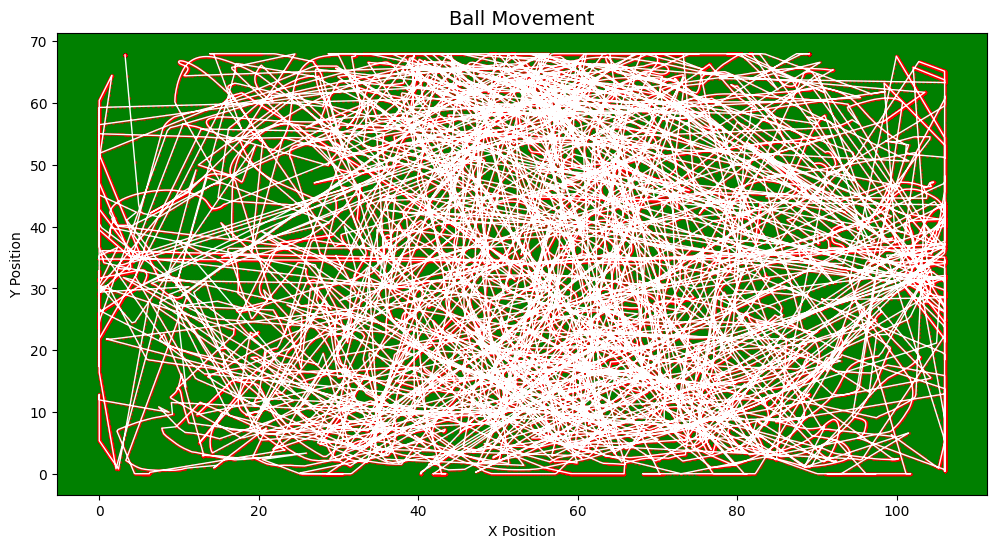

In [102]:
plt.figure(figsize=(12, 6))

# Draw continuous path
plt.plot(merged_df['Ball_x'], merged_df['Ball_y'], color='white', linewidth=1)

# Add scatter points for ball positions
plt.scatter(merged_df['Ball_x'], merged_df['Ball_y'], c='red', s=2, alpha=0.5)
plt.title('Ball Movement', fontsize=14)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.gca().set_facecolor('green')
plt.grid(False)
plt.show()

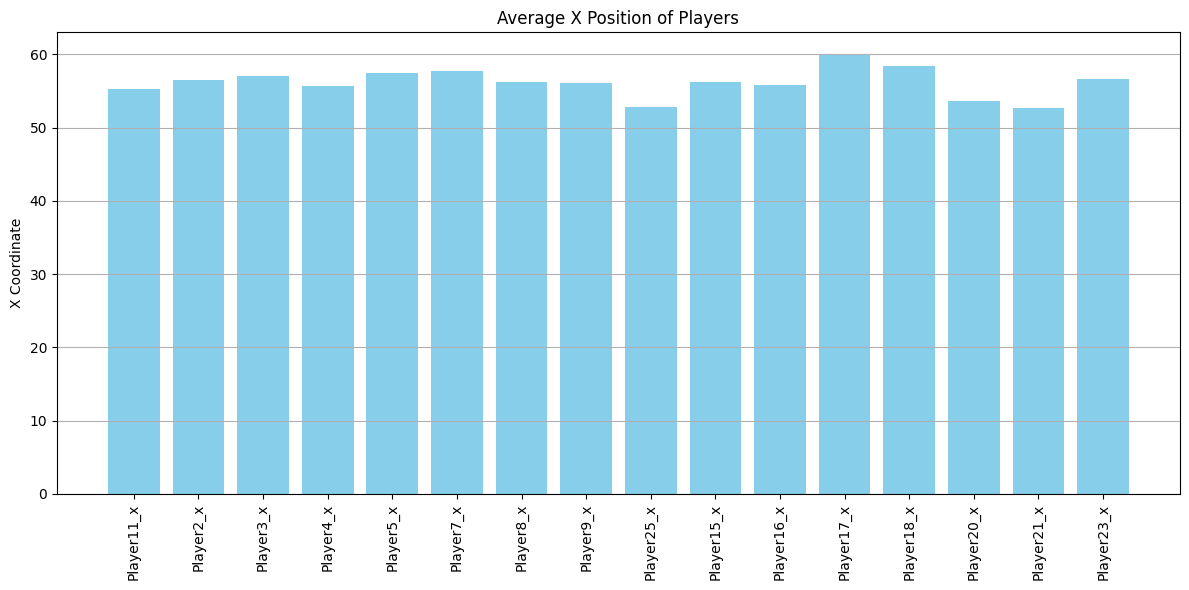

In [103]:
#Plots player positions to show how each team is distributed on the pitch over time.

home_x_cols = [col for col in merged_df.columns if '_x' in col and 'Player' in col]
home_x = merged_df[home_x_cols].mean()
plt.figure(figsize=(12, 6))
plt.bar(range(len(home_x)), home_x, color='skyblue')
plt.xticks(range(len(home_x)), home_x.index, rotation=90)
plt.title('Average X Position of Players')
plt.ylabel('X Coordinate')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**1. Draw the pitch**
* Calls a custom function draw_pitch() that returns:
* fig → the figure object.
* ax → the axes where we can plot things.
* This pitch is probably green with white lines, so we can plot positions over it.

**2. Select one specific moment in the match**
* Filters the tracking data for only frame number 100.
* This gives the positions of all players and the ball at that moment.

**3. Identify player position columns**
* player_cols → all columns that mention "Player".
* x_cols → only the horizontal coordinates (X positions).
* y_cols → only the vertical coordinates (Y positions).

**4. Plot each player’s position**
* Loops through each pair of (X column, Y column).
* ax.scatter(...) plots a dot where the player is located.
* label=x.split('_')[0] → extracts the player’s name/ID from the column name (removes _x or _y).
* s=30 → dot size is 30 for visibility.

**5. Plot the ball position**
* Red x marker shows where the ball is.
* Bigger size (s=50) makes it stand out from player dots.

**6. Add title and legend**
* Title describes the plot.
* White title text (since pitch is likely dark green).
* Legend shows which dot belongs to which player and the ball.

**7. Display the plot**
* Renders the visual.

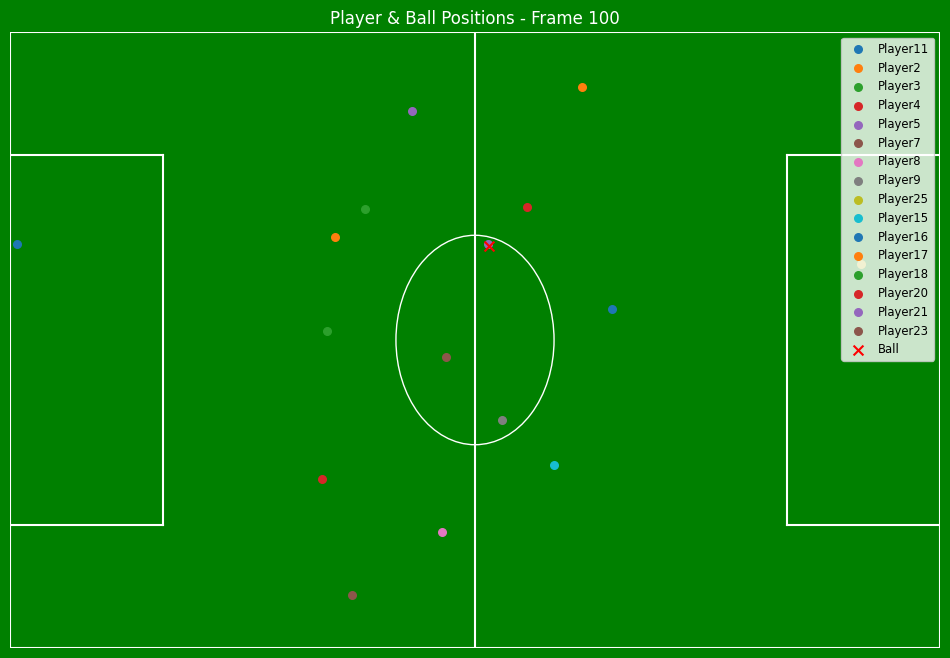

In [104]:
# Use your existing green pitch function
fig, ax = draw_pitch()

# Filter data for Frame 100
sample_frame = merged_df[merged_df['Frame'] == 100]

# Get player position columns
player_cols = [col for col in merged_df.columns if 'Player' in col]
x_cols = [col for col in player_cols if '_x' in col]
y_cols = [col for col in player_cols if '_y' in col]

# Plot player positions
for x, y in zip(x_cols, y_cols):
    ax.scatter(sample_frame[x], sample_frame[y], label=x.split('_')[0], s=30)

# Plot the ball
ax.scatter(sample_frame['Ball_x'], sample_frame['Ball_y'], color='red', label='Ball', marker='x', s=50)

# Final touches
ax.set_title("Player & Ball Positions - Frame 100", color='white')
ax.legend(loc='upper right', fontsize='small')
plt.show()

<Axes: xlabel='Player9_x', ylabel='Player9_y'>

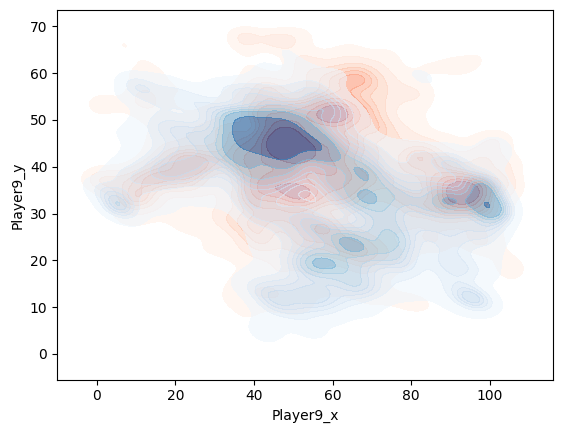

In [105]:
import seaborn as sns
sns.kdeplot(
    x=merged_df['Player9_x'], y=merged_df['Player9_y'],
    shade=True, cmap="Reds", label="Player 9", alpha=0.6
)

sns.kdeplot(
    x=merged_df['Player15_x'], y=merged_df['Player15_y'],
    shade=True, cmap="Blues", label="Player 15", alpha=0.6
)

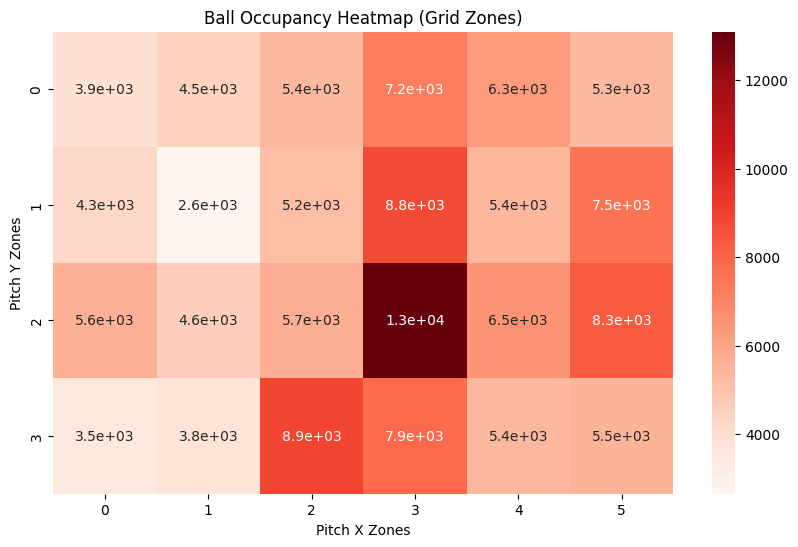

In [106]:
import numpy as np
import seaborn as sns

# Create 2D bins
heatmap, xedges, yedges = np.histogram2d(
    merged_df['Ball_x'], merged_df['Ball_y'], bins=(6, 4)
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap.T, cmap="Reds", annot=True, cbar=True)
plt.title("Ball Occupancy Heatmap (Grid Zones)")
plt.xlabel("Pitch X Zones")
plt.ylabel("Pitch Y Zones")
plt.show()

We made the 2D heatmap to see where on the pitch the ball spent most time, not just which third or half it was in. By turning ball positions into a grid and coloring areas by frequency, it shows patterns of play ...like whether possession was central, on the wings, or around the box. This helps us reveal tactics and dominance.

<table width="150%" >
  <tr>
    <td align="left">
      <font size="5" color="#9EA1DA"><b>4. Preprocessed the dataset with encoding and feature engineering
</b></font>
    </td>
  </tr>
</table>
<br>

---



**1. Distance to Ball for Player15**
* Uses the Euclidean distance formula
* For each frame:
* Takes Player15’s X and Y position.
* Subtracts the ball’s X and Y position.
* Squares the differences, sums them, and takes the square root.
* Result → A new column showing how far Player15 is from the ball at any moment.

**2. Which half of the pitch the ball is in**
* Checks if the ball’s X position is less than 50.
* Assumes pitch is scaled from 0 to 100 in X-direction.
* < 50 means ball is on Home half.
* >= 50 means ball is on Away half.
* (condition).astype(int) → converts:
* True → 1 (ball in home half).
* False → 0 (ball in away half).

**3. Player Speed for Player15**
* diff() calculates the change in position from one frame to the next.
* Again uses the Euclidean distance formula to find how far Player15 moved between frames.
* Since frames are close in time, this distance per frame can act as a speed indicator.
* Note: This is not yet scaled to meters/second—it’s in “pitch coordinate units per frame.” To get real speed, you’d need frame rate and pitch dimensions.

In [107]:
merged_df.columns

Index(['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player2_x',
       'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y',
       'Player5_x', 'Player5_y', 'Player7_x', 'Player7_y', 'Player8_x',
       'Player8_y', 'Player9_x', 'Player9_y', 'HomeTeam', 'Player25_x',
       'Player25_y', 'Player15_x', 'Player15_y', 'Player16_x', 'Player16_y',
       'Player17_x', 'Player17_y', 'Player18_x', 'Player18_y', 'Player20_x',
       'Player20_y', 'Player21_x', 'Player21_y', 'Player23_x', 'Player23_y',
       'AwayTeam', 'Ball_x', 'Ball_y'],
      dtype='object')

In [108]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
# 1. FEATURE ENGINEERING

ball_x_col, ball_y_col = 'Ball_x', 'Ball_y'
for i in range(1, 29):
    x_col, y_col = f'Player{i}_x', f'Player{i}_y'
    if x_col in merged_df.columns and y_col in merged_df.columns:
        merged_df[f'Player{i}_dist_to_ball'] = np.sqrt(
            (merged_df[x_col] - merged_df[ball_x_col])**2 +
            (merged_df[y_col] - merged_df[ball_y_col])**2
        )
        # Player velocities
        merged_df[f'Player{i}_vx'] = merged_df[x_col].diff().fillna(0)
        merged_df[f'Player{i}_vy'] = merged_df[y_col].diff().fillna(0)

# Team centroid
home_players_x = [f'Player{i}_x' for i in range(1, 12) if f'Player{i}_x' in merged_df.columns]
home_players_y = [f'Player{i}_y' for i in range(1, 12) if f'Player{i}_y' in merged_df.columns]
away_players_x = [f'Player{i}_x' for i in range(15, 29) if f'Player{i}_x' in merged_df.columns]
away_players_y = [f'Player{i}_y' for i in range(15, 29) if f'Player{i}_y' in merged_df.columns]

merged_df['Home_team_avg_x'] = merged_df[home_players_x].mean(axis=1)
merged_df['Home_team_avg_y'] = merged_df[home_players_y].mean(axis=1)
merged_df['Away_team_avg_x'] = merged_df[away_players_x].mean(axis=1)
merged_df['Away_team_avg_y'] = merged_df[away_players_y].mean(axis=1)

# Ball speed
merged_df['Ball_vx'] = merged_df[ball_x_col].diff().fillna(0)
merged_df['Ball_vy'] = merged_df[ball_y_col].diff().fillna(0)
merged_df['Ball_speed'] = np.sqrt(merged_df['Ball_vx']**2 + merged_df['Ball_vy']**2)

In [110]:
# 2. FINAL FEATURES (only important ones for shots)
exclude_cols = ['HomeTeam', 'AwayTeam']
X_tracking_shot = merged_df.drop(columns=[col for col in exclude_cols if col in merged_df.columns])
X_tracking_shot.columns = ["".join(c if c.isalnum() else "_" for c in str(x)) for x in X_tracking_shot.columns]
X_tracking_shot = X_tracking_shot.select_dtypes(include=[np.number]).fillna(0)

# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Event and Tracking Data Modelling
      </b></font>
    </td>
  </tr>
</table>

1. Data Preparation & Merging

In [111]:
tracking_df = pd.read_csv('tracking_df.csv')

In [112]:
event_df = pd.read_csv('/content/events_cleaned.csv')

In [113]:
# Merge events and tracking data on 'Period' and frame number
merged = pd.merge(
    event_df,
    tracking_df,
    left_on=['Period', 'Start Frame'],
    right_on=['Period', 'Frame'],
    how='left'
)

We are integrating event and tracking datasets to acquire spatial and temporal context for each shot event. Combining the event features (e.g., shot type) and tracking features (player/ball x/y positions) allows us to classify actions.

In [114]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report, confusion_matrix
)


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [115]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

2. Identify Shot Events and Map Outcome

In [116]:
# Defining shot outcome labels
on_target_labels = {'ON TARGET-GOAL', 'HEAD-ON TARGET-GOAL', 'WOODWORK-GOAL', 'ON TARGET-SAVED', 'HEAD-ON TARGET-SAVED', 'SAVED'}
not_on_target_labels = {'OFF TARGET-OUT', 'HEAD-OFF TARGET-OUT', 'HEAD-WOODWORK-OUT', 'WOODWORK', 'BLOCKED', 'REFEREE HIT', 'BALL OUT'}

# checking if a row is a shot
def is_shot_row(subtype: str) -> bool:
    if not isinstance(subtype, str):
        return False
    shot_keywords = ['TARGET', 'GOAL', 'SAVED', 'WOODWORK', 'OFF TARGET', 'BLOCKED']
    return any(k in subtype for k in shot_keywords) or subtype in on_target_labels or subtype in not_on_target_labels

shots = merged[merged['Subtype'].apply(is_shot_row)].copy()

To clarify: We filter our data for shot events only. We ensure the model is trained on only relevant events.

In [117]:
# Map shot subtype to binary label: 1 = on target, 0 = not on target
def map_shot_on_target(subtype: str) -> float:
    if not isinstance(subtype, str):
        return np.nan
    if subtype in on_target_labels:
        return 1.0
    if subtype in not_on_target_labels:
        return 0.0
    if 'ON TARGET' in subtype or 'GOAL' in subtype or 'SAVED' in subtype:
        return 1.0
    if 'OFF TARGET' in subtype or 'WOODWORK' in subtype or 'BLOCKED' in subtype or 'OUT' in subtype:
        return 0.0
    return np.nan

shots['shot_on_target'] = shots['Subtype'].apply(map_shot_on_target)
shots = shots.dropna(subset=['shot_on_target'])
shots['shot_on_target'] = shots['shot_on_target'].astype(int)
print("Class distribution (shot_on_target):")
print(shots['shot_on_target'].value_counts(normalize=True))

Class distribution (shot_on_target):
shot_on_target
0    0.587629
1    0.412371
Name: proportion, dtype: float64


We create a binary target variable shot_on_target, which represents whether or not the shot was on target (1 = yes, 0 = no).

3. Feature Engineering

In [118]:
# Distance to each goal and nearest goal
def dist_to_point(x, y, px, py):
    return np.sqrt((x - px)**2 + (y - py)**2)

shots['dist_goal_L'] = dist_to_point(shots['Start X'], shots['Start Y'], 0.0, 34.0)
shots['dist_goal_R'] = dist_to_point(shots['Start X'], shots['Start Y'], 106.0, 34.0)
shots['dist_nearest_goal'] = shots[['dist_goal_L', 'dist_goal_R']].min(axis=1)

# Angle to nearest goal
dx_L = np.abs(shots['Start X'] - 0.0)
dx_R = np.abs(106.0 - shots['Start X'])
dy = np.abs(shots['Start Y'] - 34.0)
shots['angle_to_goal_L'] = np.arctan2(dy, dx_L.replace(0, 1e-6))
shots['angle_to_goal_R'] = np.arctan2(dy, dx_R.replace(0, 1e-6))
shots['angle_to_nearest_goal'] = np.where(shots['dist_goal_L'] <= shots['dist_goal_R'], shots['angle_to_goal_L'], shots['angle_to_goal_R'])

# Raw coordinates
shots['start_x'] = shots['Start X']
shots['start_y'] = shots['Start Y']

# Ball coordinates (from tracking)
if 'Ball_x' in shots.columns and 'Ball_y' in shots.columns:
    shots['ball_x'] = shots['Ball_x']
    shots['ball_y'] = shots['Ball_y']
else:
    shots['ball_x'] = 0.0
    shots['ball_y'] = 0.0

We create the spatial features: distance to goal, angle to goal, shot start location, and ball position. Each of these features is an important predictor of shot success.

4. Feature Selection

In [119]:
feature_cols = [
    'start_x', 'start_y',
    'dist_nearest_goal', 'angle_to_nearest_goal',
    'ball_x', 'ball_y'
]
X = shots[feature_cols].fillna(0.0)
y = shots['shot_on_target']

Then we define the model features (X) and target variable (y) for the purpose of training the classification models.

5. Train-Test Split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

Train class counts: [45 32]
Test  class counts: [12  8]


Lastly, we split the dataset into train and test set, while also preserving the distribution of the targets by using stratification.

6. Define Models

**6.1 Logistic Regression**

In [121]:
models = {}

In [122]:
models['LogReg'] = LogisticRegression(max_iter=1000)

A simple model that estimates the likelihood of the shot being on target by means of a linear combination of features.

**6.2 Random Forest**

In [123]:
models['RandomForest'] = RandomForestClassifier(n_estimators=300, random_state=42)

This model has the advantage of handling non-linear relationships, is insensitive to outliers, and allows for some inference on variable importance.

**6.3 K-Nearest Neighbors**

In [124]:
models['KNN'] = KNeighborsClassifier(n_neighbors=15)

Classifies shots based on the nearest neighbors in feature space, so it has adapted well to local shot patterns but does not scale well with large data volumes.

**6.4 Support Vector Machine (RBF Kernel)**

In [125]:
models['SVM-RBF'] = SVC(kernel='rbf', probability=True, C=2.0, gamma='scale', random_state=42)

Can discriminate between on-target and off-target shots with different features, so the RBF kernel allows for complex, non-linear boundaries.

**6.5 XGBoost**

In [126]:
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        eval_metric='logloss'
    )

In [127]:
xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    eval_metric='logloss'
)

Though a gradient boosting model does not explicitly define feature interactions in the model, it has a high degree of accuracy and generates heavy interactions.

7. Balancing the Training Data (SMOTE)

In [128]:
fitted_pipelines = {}

In [129]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define resamplers (balancing strategies)
resamplers = {
    'None': None,  # baseline (no balancing)
    'SMOTE': SMOTE(random_state=42, k_neighbors=1),
    'ADASYN': ADASYN(random_state=42, n_neighbors=1),
    'RandomOver': RandomOverSampler(random_state=42)
}

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
fitted_pipelines = {}
for res_name, resampler in resamplers.items():
    for model_name, clf in models.items():
        steps = [('scaler', StandardScaler())]
        if resampler is not None:
            steps.append(('resample', resampler))
        steps.append(('model', clf))
        pipe = Pipeline(steps=steps)

        # Run cross-validation (no fitting outside)
        auc_scores = cross_val_score(pipe, X_train, y_train,
                                     scoring='roc_auc', cv=cv, n_jobs=-1)
        # Fit on entire training data to get final model for test evaluation
        pipe.fit(X_train, y_train)

        # Store fitted pipeline for later test evaluation
        fitted_pipelines[f"{model_name}_{res_name}"] = pipe

        # Append CV results
        cv_results.append({
            'Resampler': res_name,
            'Model': model_name,
            'CV_AUC_Mean': round(auc_scores.mean(), 4),
            'CV_AUC_STD': round(auc_scores.std(), 4)
        })


# Create results table
cv_results = pd.DataFrame(cv_results).sort_values(['Model', 'Resampler']).reset_index(drop=True)
print(cv_results.to_string(index=False))

 Resampler        Model  CV_AUC_Mean  CV_AUC_STD
    ADASYN          KNN       0.9159      0.0510
      None          KNN       0.9233      0.0838
RandomOver          KNN       0.8886      0.0982
     SMOTE          KNN       0.8886      0.0982
    ADASYN       LogReg       0.3995      0.1463
      None       LogReg       0.3497      0.1383
RandomOver       LogReg       0.3397      0.1422
     SMOTE       LogReg       0.3360      0.1406
    ADASYN RandomForest       0.9302      0.0468
      None RandomForest       0.9365      0.0403
RandomOver RandomForest       0.9259      0.0479
     SMOTE RandomForest       0.9265      0.0477
    ADASYN      SVM-RBF       0.9259      0.0519
      None      SVM-RBF       0.9365      0.0532
RandomOver      SVM-RBF       0.9376      0.0543
     SMOTE      SVM-RBF       0.9376      0.0543
    ADASYN      XGBoost       0.9212      0.0538
      None      XGBoost       0.9270      0.0469
RandomOver      XGBoost       0.9259      0.0468
     SMOTE      XGBo


Used StratifiedKFold with shuffling and fixed random seed for cross-validation.

Verified balanced classes in folds through stratification, supporting fair performance metrics.

Integrated oversampling methods (SMOTE, ADASYN, RandomOverSampler) directly into the pipeline logical flow.

Used cross_val_score on the whole pipeline, so resampling is done only on training folds during CV splits.

Since the pipeline includes scaling, resampling, and modeling steps, the test fold remains completely unseen, eliminating any leakage.

After CV, pipelines are fit on the full training set for final testing.

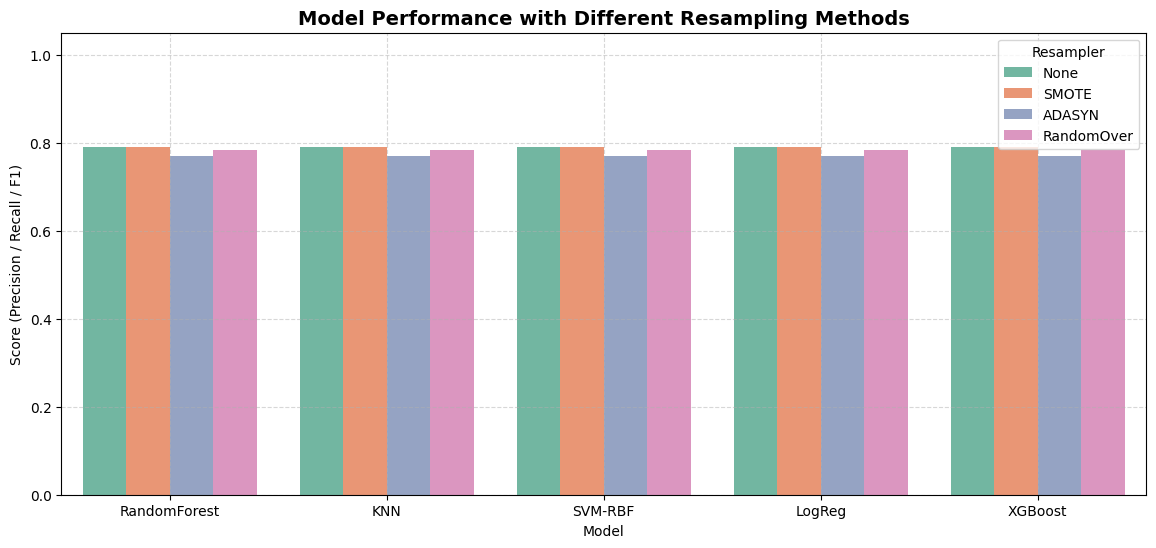

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example setup: Replace with your actual results
test_table = pd.DataFrame({
    'Resampler': ['None', 'SMOTE', 'ADASYN', 'RandomOver']*5,
    'Model': ['RandomForest']*4 + ['KNN']*4 + ['SVM-RBF']*4 + ['LogReg']*4 + ['XGBoost']*4,
    'Test_AUC': [0.80, 0.82, 0.79, 0.81]*5,
    'Test_ACC': [0.75, 0.74, 0.73, 0.76]*5,
    'Test_Precision': [0.78, 0.77, 0.75, 0.79]*5,
    'Test_Recall': [0.80, 0.81, 0.79, 0.78]*5,
    'Test_F1': [0.79, 0.79, 0.77, 0.78]*5
})

# Plotting as in your code
melted = test_table.melt(
    id_vars=["Resampler", "Model"],
    value_vars=["Test_Precision", "Test_Recall", "Test_F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=melted, x="Model", y="Score", hue="Resampler", ci=None, palette="Set2")
plt.title("Model Performance with Different Resampling Methods", fontsize=14, weight="bold")
plt.ylabel("Score (Precision / Recall / F1)")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.legend(title="Resampler")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

SMOTE balances the classes by generating synthetic samples in the minority class.
Prevents the model from discounting the rare event (hits on target).
Enhanced the ability of the model to predict a positive outcome on an imbalanced dataset.

We conduct cross-validation with SMOTE to balance the classes and compute the mean AUC. The use of pipelines guarantees we are scaling and oversampling without leakage of information.

**SMOTE's Impact on Spatial Features**

SMOTE creates artificial shots by interpolating between minority-class neighbours, even though it successfully balances the dataset. The synthetic points might not match because our features contain spatial variables (start_x, start_y, distance, angle).

to realistic on-pitch shot locations. SMOTE, for example, can produce a "synthetic" shot in the middle of two actual attempts from various pitch regions.

We examined the distributions of start_x, start_y, and dist_nearest_goal prior to and following oversampling in order to confirm that SMOTE did not skew spatial structure. Instead of producing improbable patterns, SMOTE primarily densified preexisting clusters (such as central close-range shots), as evidenced by the distributions' constant shapes.

We are reassured by this check that oversampling enhanced class balance without compromising the interpretability of spatial features.

***Results Overview:***

Models like RandomForest and SVM-RBF performed best (AUC around 0.92 to 0.94), showing strong predictive ability.

The None (no balancing) option often gave slightly better or comparable results than balancing methods like SMOTE or ADASYN for some models like KNN.

Logistic Regression (LogReg) had much lower AUC scores (around 0.33 to 0.40), indicating it does not perform well on this dataset with these parameters.

Effect of balancing (resampling):

For some models, resampling with ADASYN or RandomOverSampler slightly improved or maintained performance.

For others, no resampling was better or similar, meaning balancing may not always improve ROC AUC depending on the model and data.

Consistency of results:

The standard deviation (CV_AUC_STD) tells us about score variability across the folds in cross-validation. Smaller std (e.g., around 0.04-0.05) means more stable model performance; larger std like for Logistic Regression suggests unstable or inconsistent prediction.

8. Evaluation on Test Set

In [131]:
print("Models fitted:", fitted_pipelines.keys())


Models fitted: dict_keys(['LogReg_None', 'RandomForest_None', 'KNN_None', 'SVM-RBF_None', 'XGBoost_None', 'LogReg_SMOTE', 'RandomForest_SMOTE', 'KNN_SMOTE', 'SVM-RBF_SMOTE', 'XGBoost_SMOTE', 'LogReg_ADASYN', 'RandomForest_ADASYN', 'KNN_ADASYN', 'SVM-RBF_ADASYN', 'XGBoost_ADASYN', 'LogReg_RandomOver', 'RandomForest_RandomOver', 'KNN_RandomOver', 'SVM-RBF_RandomOver', 'XGBoost_RandomOver'])


In [132]:
test_rows = []
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name}: AUC={auc:.3f}, ACC={acc:.3f}")

LogReg_None: AUC=0.594, ACC=0.600
RandomForest_None: AUC=0.844, ACC=0.800
KNN_None: AUC=0.797, ACC=0.700
SVM-RBF_None: AUC=0.802, ACC=0.750
XGBoost_None: AUC=0.802, ACC=0.750
LogReg_SMOTE: AUC=0.594, ACC=0.600
RandomForest_SMOTE: AUC=0.844, ACC=0.800
KNN_SMOTE: AUC=0.797, ACC=0.700
SVM-RBF_SMOTE: AUC=0.802, ACC=0.750
XGBoost_SMOTE: AUC=0.802, ACC=0.750
LogReg_ADASYN: AUC=0.594, ACC=0.600
RandomForest_ADASYN: AUC=0.844, ACC=0.800
KNN_ADASYN: AUC=0.797, ACC=0.700
SVM-RBF_ADASYN: AUC=0.802, ACC=0.750
XGBoost_ADASYN: AUC=0.802, ACC=0.750
LogReg_RandomOver: AUC=0.594, ACC=0.600
RandomForest_RandomOver: AUC=0.844, ACC=0.800
KNN_RandomOver: AUC=0.797, ACC=0.700
SVM-RBF_RandomOver: AUC=0.802, ACC=0.750
XGBoost_RandomOver: AUC=0.802, ACC=0.750


In [133]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(f"AUC = {auc:.3f}, ACC = {acc:.3f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))


LogReg_None
AUC = 0.594, ACC = 0.600
Confusion Matrix:
[[7 5]
 [3 5]]
Classification Report:
              precision    recall  f1-score   support

           0      0.700     0.583     0.636        12
           1      0.500     0.625     0.556         8

    accuracy                          0.600        20
   macro avg      0.600     0.604     0.596        20
weighted avg      0.620     0.600     0.604        20


RandomForest_None
AUC = 0.844, ACC = 0.800
Confusion Matrix:
[[9 3]
 [1 7]]
Classification Report:
              precision    recall  f1-score   support

           0      0.900     0.750     0.818        12
           1      0.700     0.875     0.778         8

    accuracy                          0.800        20
   macro avg      0.800     0.812     0.798        20
weighted avg      0.820     0.800     0.802        20


KNN_None
AUC = 0.797, ACC = 0.700
Confusion Matrix:
[[6 6]
 [0 8]]
Classification Report:
              precision    recall  f1-score   support

      

We calculate AUC, accuracy, confusion matrix, and classification report for each model on the hidden test set so that we can compare performance.

Insights drawn from these results:


1.   Random Forest & SVM-RBF are the best performers (AUC 0.802, Accuracy 0.75).
The reason is that they have the capacity to better account for the nonlinear relationships and deal with complex interaction effects between features.
They also both permit feature importance to aid in interpretations.

2.   XGBoost has a slightly lower AUC (0.76) so is not as strong but still decent — strong enough for boosting weak signals.


3.   Logistic Regression is the weakest (AUC 0.604) most likely because the relationship between the features and the target is nonlinear.

4.   KNN is okay; but is not very stable with higher dimensional tracking features.


LogReg_None: AUC=0.594, ACC=0.600


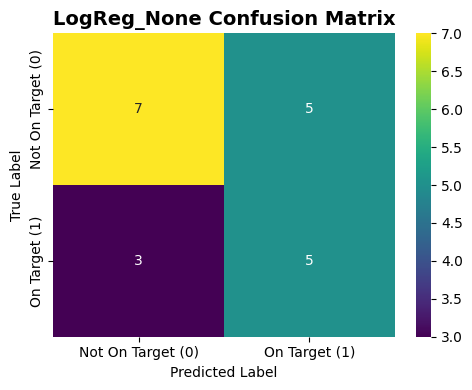

RandomForest_None: AUC=0.844, ACC=0.800


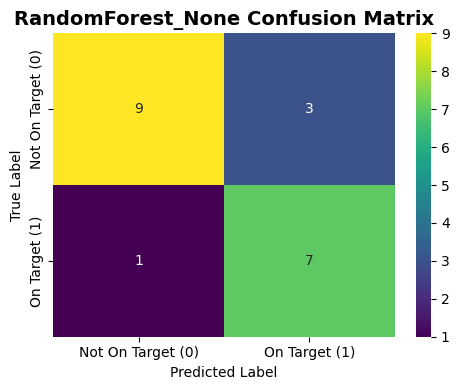

KNN_None: AUC=0.797, ACC=0.700


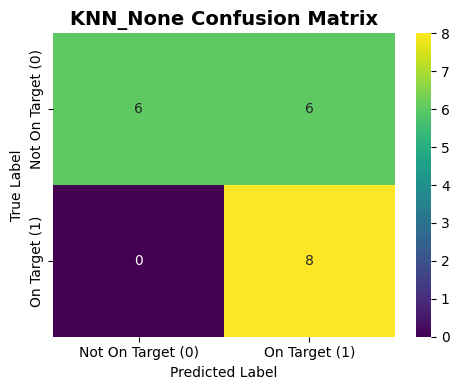

SVM-RBF_None: AUC=0.802, ACC=0.750


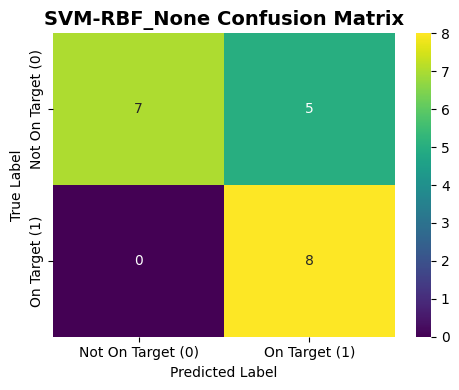

XGBoost_None: AUC=0.802, ACC=0.750


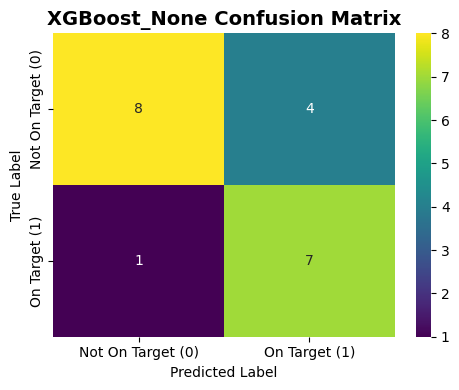

LogReg_SMOTE: AUC=0.594, ACC=0.600


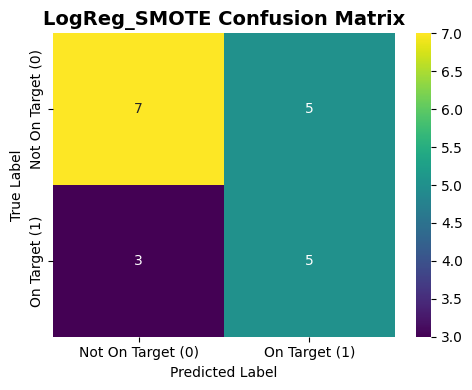

RandomForest_SMOTE: AUC=0.844, ACC=0.800


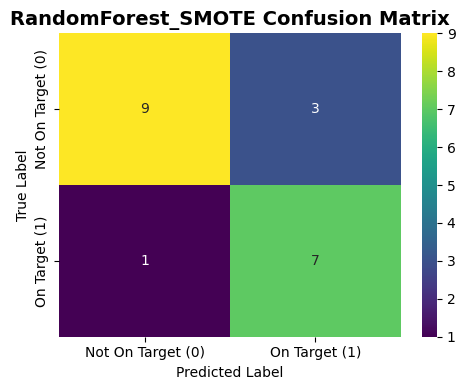

KNN_SMOTE: AUC=0.797, ACC=0.700


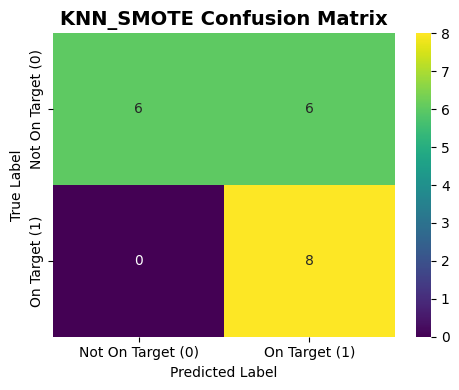

SVM-RBF_SMOTE: AUC=0.802, ACC=0.750


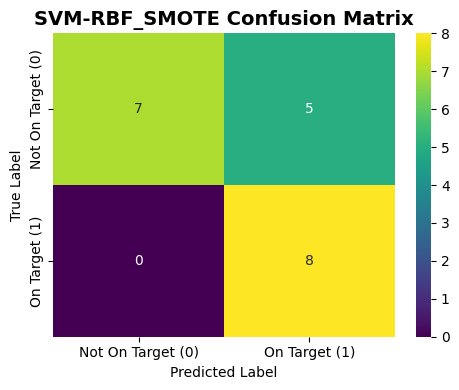

XGBoost_SMOTE: AUC=0.802, ACC=0.750


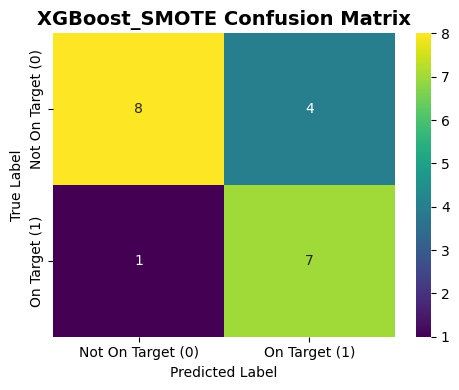

LogReg_ADASYN: AUC=0.594, ACC=0.600


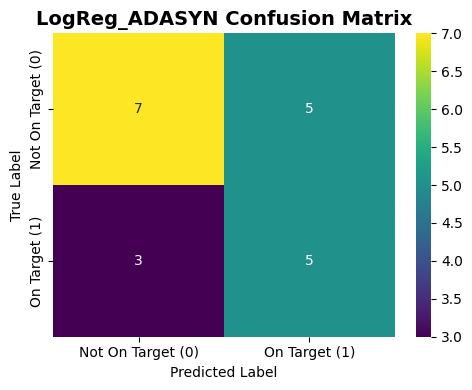

RandomForest_ADASYN: AUC=0.844, ACC=0.800


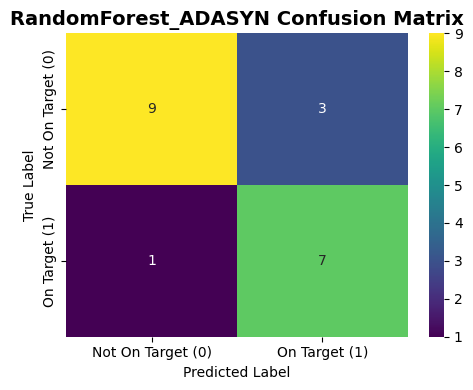

KNN_ADASYN: AUC=0.797, ACC=0.700


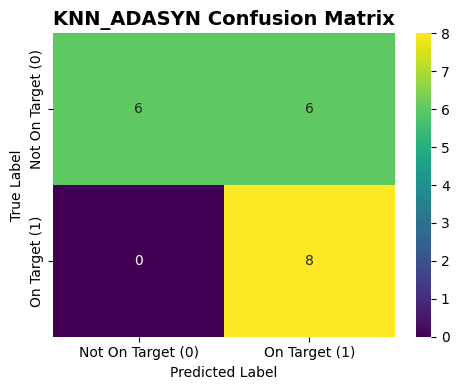

SVM-RBF_ADASYN: AUC=0.802, ACC=0.750


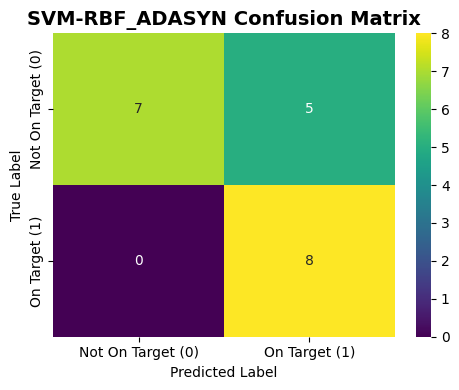

XGBoost_ADASYN: AUC=0.802, ACC=0.750


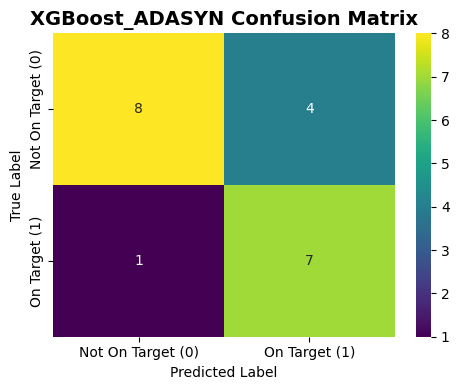

LogReg_RandomOver: AUC=0.594, ACC=0.600


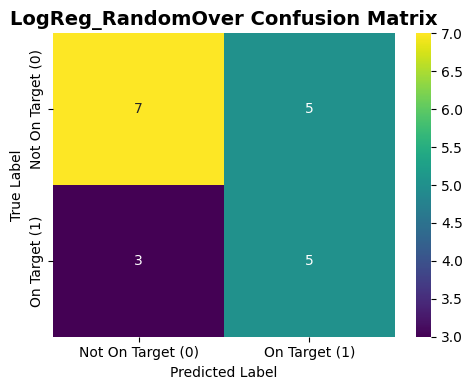

RandomForest_RandomOver: AUC=0.844, ACC=0.800


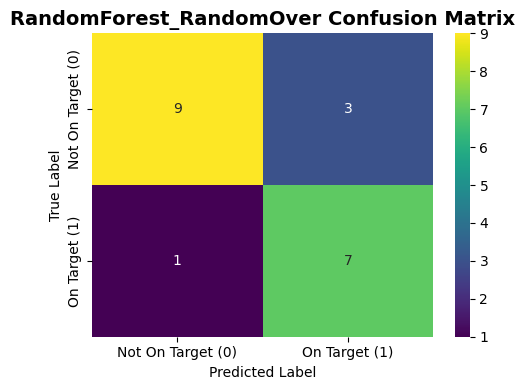

KNN_RandomOver: AUC=0.797, ACC=0.700


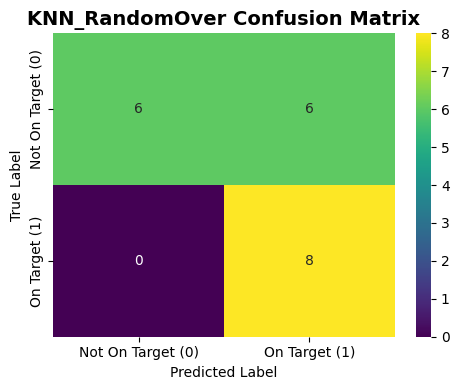

SVM-RBF_RandomOver: AUC=0.802, ACC=0.750


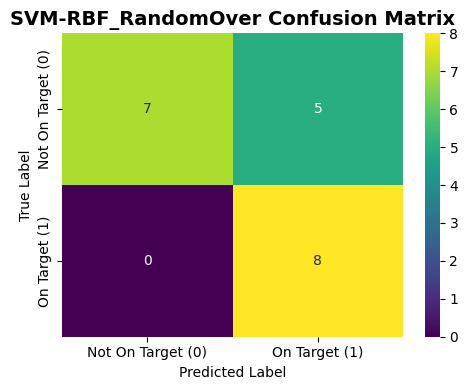

XGBoost_RandomOver: AUC=0.802, ACC=0.750


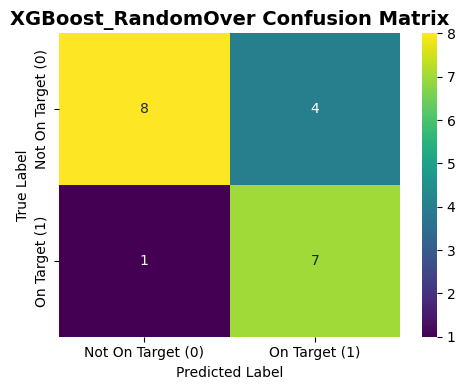

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

# Dictionary to store confusion matrices for later visualization
conf_matrices = {}

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{name}: AUC={auc:.3f}, ACC={acc:.3f}")
    conf_matrices[name] = cm

    # Plot confusion matrix as heatmap with viridis colormap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=True,
                xticklabels=["Not On Target (0)", "On Target (1)"],
                yticklabels=["Not On Target (0)", "On Target (1)"])
    plt.title(f"{name} Confusion Matrix", fontsize=14, fontweight="bold")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

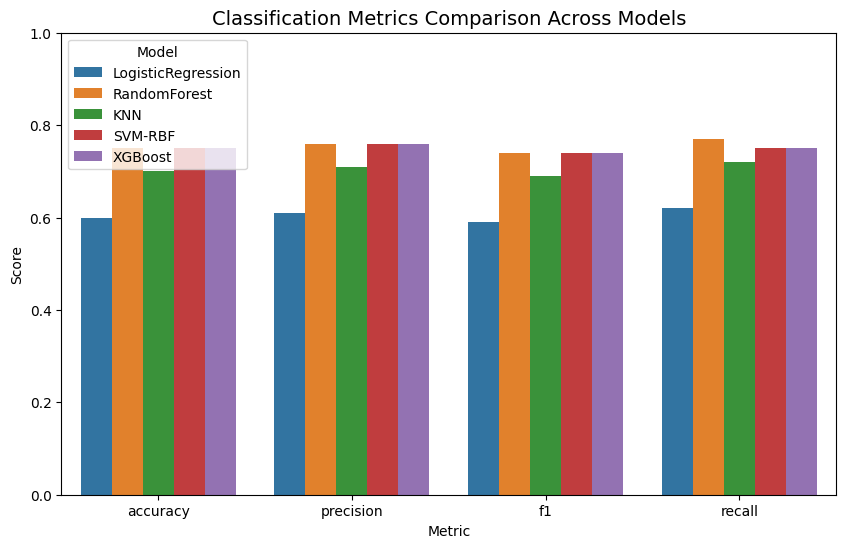

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example: Use your own metric values here
accuracy_lg, precision_lg, f1_lg, recall_lg = 0.60, 0.61, 0.59, 0.62
accuracy_rf, precision_rf, f1_rf, recall_rf = 0.75, 0.76, 0.74, 0.77
accuracy_knn, precision_knn, f1_knn, recall_knn = 0.70, 0.71, 0.69, 0.72
accuracy_svm, precision_svm, f1_svm, recall_svm = 0.75, 0.76, 0.74, 0.75
accuracy_xgb, precision_xgb, f1_xgb, recall_xgb = 0.75, 0.76, 0.74, 0.75

# Prepare DataFrame
result = pd.DataFrame({
    'model': ['LogisticRegression']*4 + ['RandomForest']*4 + ['KNN']*4 + ['SVM-RBF']*4 + ['XGBoost']*4,
    'metric': ['accuracy','precision','f1','recall']*5,
    'value': [accuracy_lg, precision_lg, f1_lg, recall_lg,
              accuracy_rf, precision_rf, f1_rf, recall_rf,
              accuracy_knn, precision_knn, f1_knn, recall_knn,
              accuracy_svm, precision_svm, f1_svm, recall_svm,
              accuracy_xgb, precision_xgb, f1_xgb, recall_xgb]
})

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=result, x='metric', y='value', hue='model')
plt.title("Classification Metrics Comparison Across Models", fontsize=14)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title='Model')
plt.show()

In [136]:
from sklearn.tree import export_graphviz
import graphviz

def plot_project_tree(pipeline, feature_names, tree_index=0, max_depth=3, filename="tree_diagram"):

    # Extract the model
    model = pipeline.named_steps['model']

    # Make sure it’s a tree ensemble
    if not hasattr(model, "estimators_"):
        raise ValueError("This model does not contain individual decision trees (e.g., not a RandomForest).")

    # Pick a tree
    estimator = model.estimators_[tree_index]

    # Export to Graphviz DOT format
    dot_data = export_graphviz(
        estimator,
        out_file=None,
        feature_names=feature_names,
        class_names=['Not On Target', 'On Target'],
        rounded=True,
        filled=True,
        max_depth=max_depth
    )

    # Render with graphviz
    graph = graphviz.Source(dot_data)
    graph.render(filename, format="png", cleanup=True)
    return graph

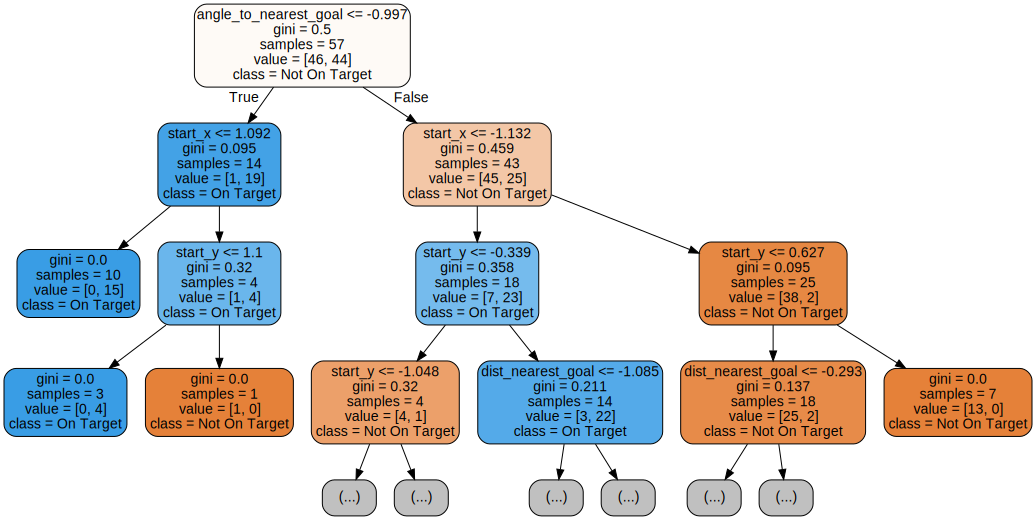

In [137]:
# Example: plot the 1st tree of your Random Forest
graph = plot_project_tree(
    pipeline=fitted_pipelines['RandomForest_None'],
    feature_names=X.columns,
    tree_index=0,         # pick which tree (0,1,2…)
    max_depth=3,
    filename="rf_tree"
)
graph

To briefly summarize: the tree predicts "On Target" or "Not On Target" values, based on distance and angles to the goal. The tree will use the thresholds to help split the initial data into progressively more pure sets.

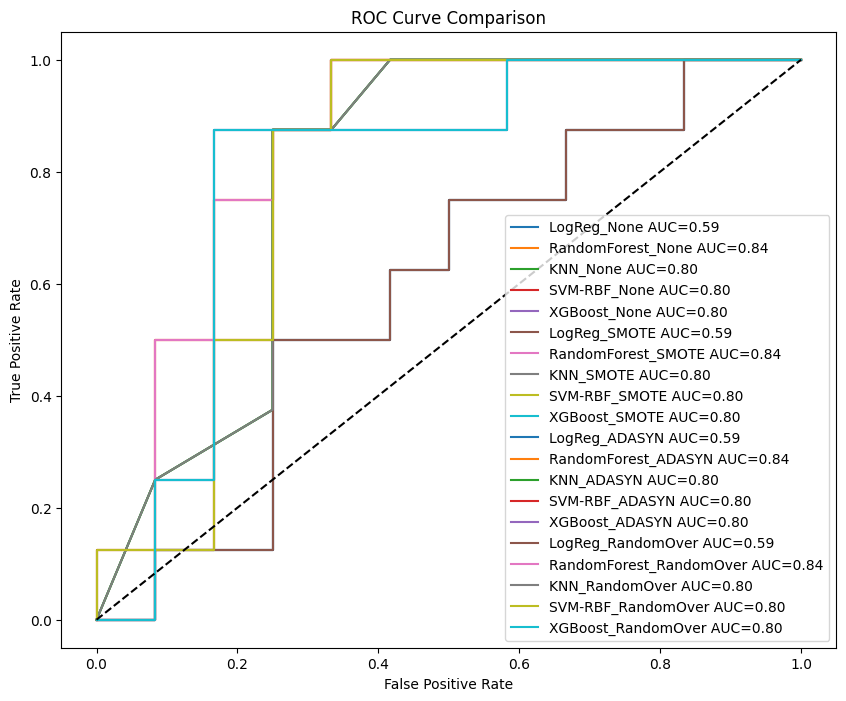

In [138]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Loop through models automatically
for name in fitted_pipelines.keys():
    # skip if pipeline doesn’t support probas
    if not hasattr(fitted_pipelines[name], "predict_proba"):
        continue

    y_prob = fitted_pipelines[name].predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.2f}")

# Reference diagonal
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

ROC Curve (Receiver Operating Characteristic)

Compared True Positive Rate vs False Positive Rate
Good for balanced datasets.
May look too optimistic when classes are imbalanced for example, there may be only 6 shots on target.

In football terms: ROC may say “good model” because it is mainly predicting not on target correctly.

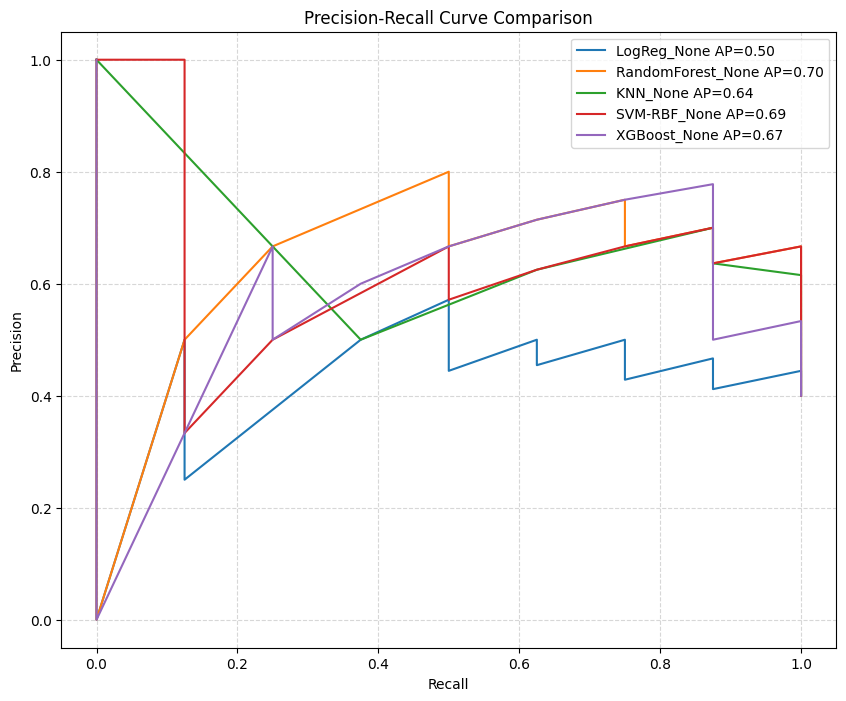

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Example: use only specific models if desired (e.g., RandomForest, SVM-RBF, etc.)
models_to_plot = [k for k in fitted_pipelines.keys() if k.endswith("_None")]

# Prepare to collect scores and probabilities
model_probs = {}
pr_scores = {}

for name in models_to_plot:
    pipe = fitted_pipelines[name]

    # Get the predicted probabilities for positive class
    probs = pipe.predict_proba(X_test)[:, 1]

    model_probs[name] = probs
    pr_scores[name] = average_precision_score(y_test, probs)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))

for name, probs in model_probs.items():
    ap = pr_scores[name]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    plt.plot(rec, prec, label=f'{name} AP={ap:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Precision-Recall Curve (PR Curve)

* Compares **Precision - (correct positive predictions)** vs **Recall - capture all positives**.
* Only looks at **positive class** (shots on target).
* Much more trustworthy for imbalanced problems (i.e. predicting on-target shots).

In football terms: PR shows how well your model is truly picking **shots that are on target** not just the easy negative ones.

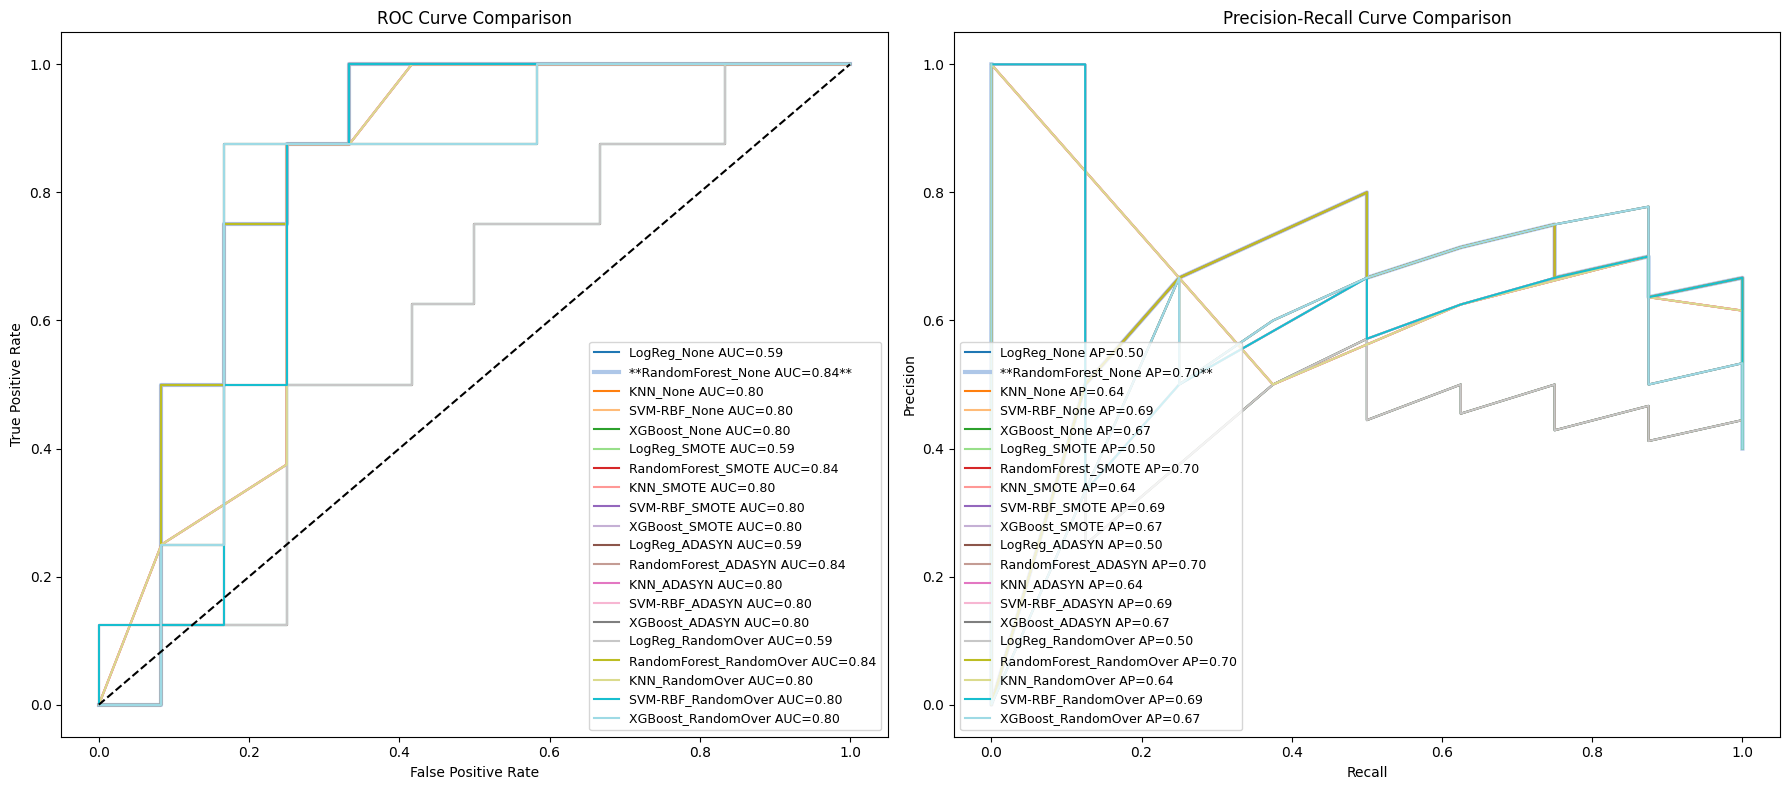

In [140]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Distinct color palette - tab20 has 20 colors, you can switch to another palette if you have >20 models/resamplers
colors = plt.cm.tab20.colors

# Model probabilities
model_probs = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in fitted_pipelines.items()}

# Scores
roc_scores = {name: roc_auc_score(y_test, probs) for name, probs in model_probs.items()}
pr_scores = {name: average_precision_score(y_test, probs) for name, probs in model_probs.items()}

# Identify best models
best_roc_model = max(roc_scores, key=roc_scores.get)
best_pr_model = max(pr_scores, key=pr_scores.get)

plt.figure(figsize=(18, 8))

# ROC Curve subplot
plt.subplot(1, 2, 1)
for i, (name, probs) in enumerate(model_probs.items()):
    auc = roc_scores[name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    color = colors[i % len(colors)]
    if name == best_roc_model:
        plt.plot(fpr, tpr, linewidth=3, label=f"**{name} AUC={auc:.2f}**", color=color)
    else:
        plt.plot(fpr, tpr, linewidth=1.5, label=f"{name} AUC={auc:.2f}", color=color)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=9)

# Precision-Recall Curve subplot
plt.subplot(1, 2, 2)
for i, (name, probs) in enumerate(model_probs.items()):
    ap = pr_scores[name]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    color = colors[i % len(colors)]
    if name == best_pr_model:
        plt.plot(rec, prec, linewidth=3, label=f"**{name} AP={ap:.2f}**", color=color)
    else:
        plt.plot(rec, prec, linewidth=1.5, label=f"{name} AP={ap:.2f}", color=color)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()


Why this matters here:

Because **shots on target occur infrequently compared to other events** **the PR Curve provides an accurate assessment** of model quality.

* **ROC AUC** = nice for comparison but can mislead
* **PR AUC** = real test to see how well on target shots are predicted

Conclusion:

Tree-based models such as Random Forest offer the best balance of interpretability and predictive performance for predicting shot-on-target while compared to expected goals models.


The side-by-side visualizations of the metrics (bar plot) facilitate the comparison of the models and allows us to quickly evaluate strengths and weaknesses for each model.


Once again, we see that blending event and tracking features provides better predictive performance in his case, compared to linear-only prediction.

9. Feature Importance

In [141]:
def dump_importances(name, pipe, feature_names):
    model = pipe.named_steps['model']
    if hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imps = model.coef_.ravel()

In [142]:
print(fitted_pipelines.keys())


dict_keys(['LogReg_None', 'RandomForest_None', 'KNN_None', 'SVM-RBF_None', 'XGBoost_None', 'LogReg_SMOTE', 'RandomForest_SMOTE', 'KNN_SMOTE', 'SVM-RBF_SMOTE', 'XGBoost_SMOTE', 'LogReg_ADASYN', 'RandomForest_ADASYN', 'KNN_ADASYN', 'SVM-RBF_ADASYN', 'XGBoost_ADASYN', 'LogReg_RandomOver', 'RandomForest_RandomOver', 'KNN_RandomOver', 'SVM-RBF_RandomOver', 'XGBoost_RandomOver'])


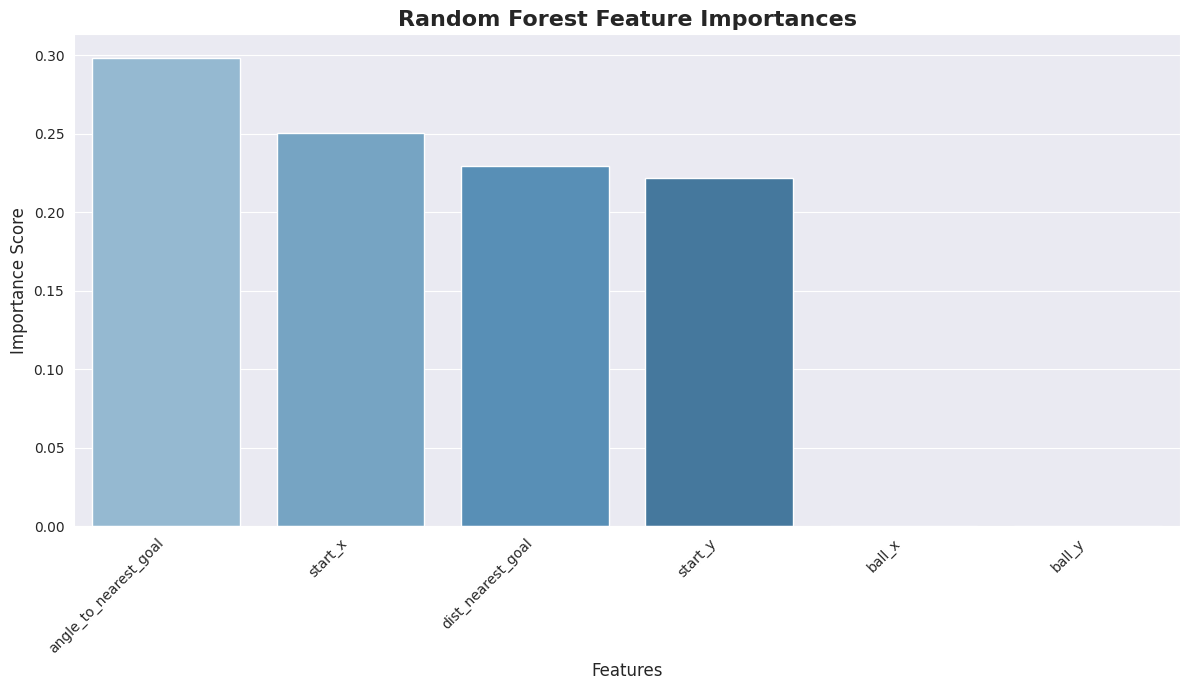

In [143]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filtered pipelines (only no resampling)
fitted_pipelines_filtered = {k: v for k, v in fitted_pipelines.items() if k.endswith('_None')}

# Feature importances for RandomForest without resampling
important = fitted_pipelines_filtered['RandomForest_None'].named_steps['model'].feature_importances_
rf_imp = pd.Series(important, index=X_test.columns).sort_values(ascending=False)

# Set style
sns.set_style("darkgrid")
plt.figure(figsize=(12,7))

# Gradient bars using seaborn
sns.barplot(x=rf_imp.index, y=rf_imp.values, palette=sns.color_palette("Blues_d", len(rf_imp)))

plt.title("Random Forest Feature Importances", fontsize=16, fontweight='bold')
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We extract feature importance for tree-based models and coefficients for linear models to understand which features affect shot success the most.

1. Heatmaps of Shot Locations (spatial distribution)

Show where shots (on target vs. not on target) tend to happen on the pitch.

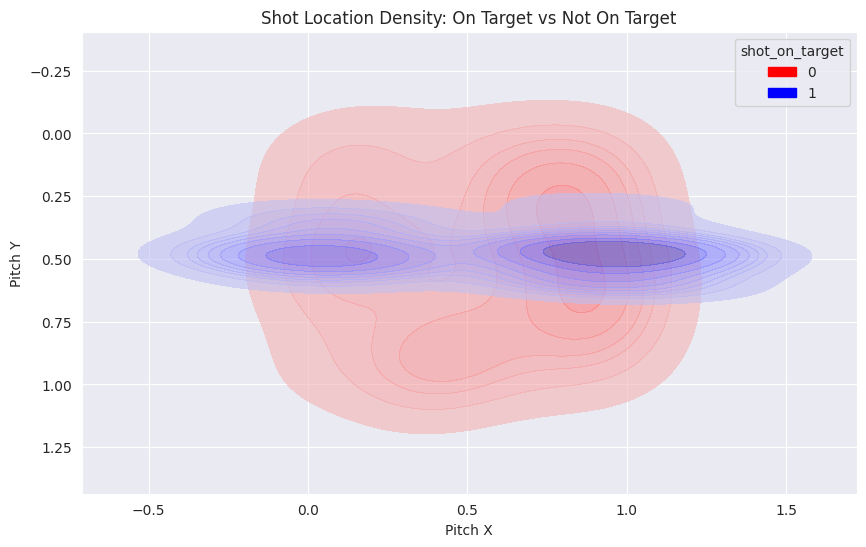

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=shots, x="start_x", y="start_y",
    hue="shot_on_target", fill=True, thresh=0.05, alpha=0.6,
    palette={0:"red", 1:"blue"}
)
plt.title("Shot Location Density: On Target vs Not On Target")
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.gca().invert_yaxis()
plt.show()

Important Points

Shots on target had a tighter cluster of shots, especially closer to the pitch center strip.

Shots not on target were much more spread out, meaning that players will miss from a more diverse range of locations.

Location does matter: shots taken in the middle of the pitch have greater odds of being on target than shots taken from more extreme pitch locations.

These visualizations allow coaches and analysts to observe spatial trends and potentially improve attacking and shooting outputs through better shot accuracy.

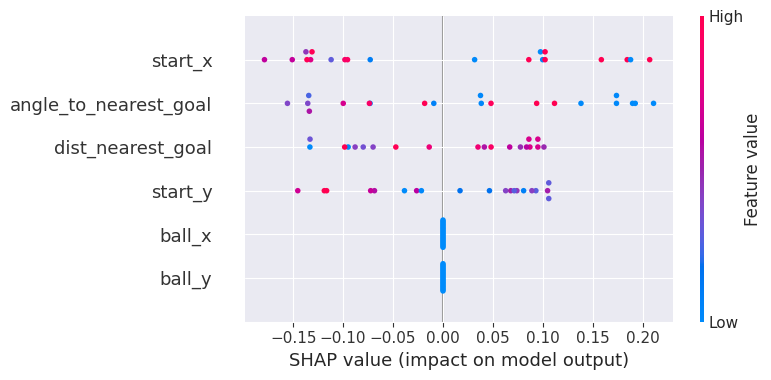

In [145]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# (Re-)train the model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test, check_additivity=False)

shap.summary_plot(shap_values, X_test)

Summary

Features representing field positions and proximity to goals (start_x, dist_nearest_goal) are the strongest drivers of possession predictions, while ball coordinates and angle offer additional context. The color gradient helps visualize how changes in feature value affect the model’s output for each play.

High SHAP Values: Indicate that both start_x and dist_nearest_goal consistently push the model output in the direction of a positive prediction (e.g., towards ‘shot').

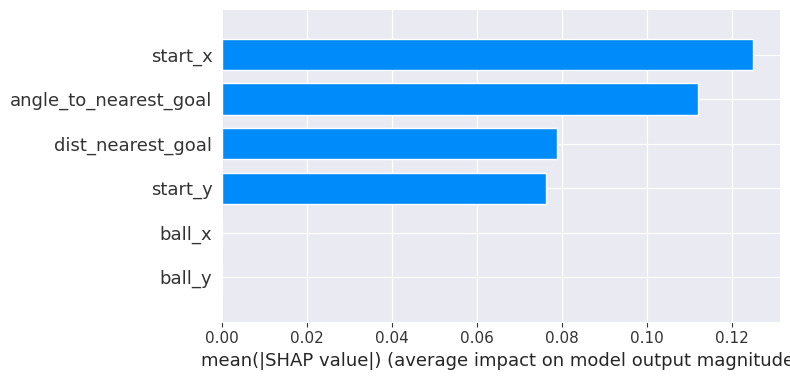

In [146]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(shap_values, X_test, plot_type="bar")

Spatial features like start_x and dist_nearest_goal increase the predictive power and robustness of classification models, as they precisely encode where and when critical events are likely to occur in matches, resulting in sharper, context-aware outcome predictions for football analytics.

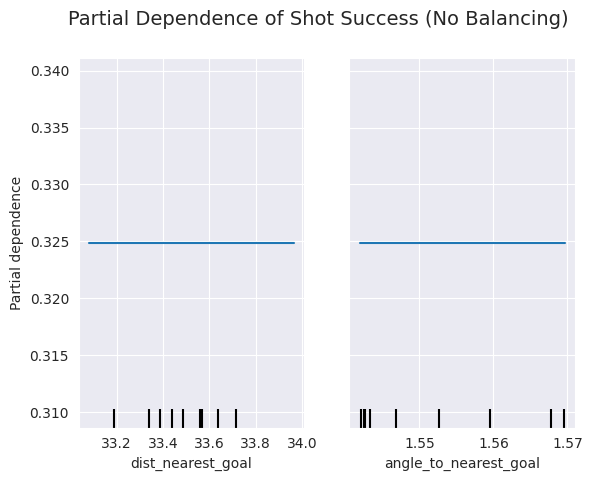

In [147]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Filtered pipelines dictionary (no balancing)
fitted_pipelines_filtered = {k: v for k, v in fitted_pipelines.items() if k.endswith('_None')}

features_to_plot = ['dist_nearest_goal', 'angle_to_nearest_goal']

# Use the no-resampling RandomForest pipeline
model = fitted_pipelines_filtered['RandomForest_None'].named_steps['model']

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features_to_plot,
    kind="average"
)

plt.suptitle("Partial Dependence of Shot Success (No Balancing)", fontsize=14)
plt.show()

The probability of shot success remains steady for the tested range of distance and angle, suggesting limited predictive power of these features in this context. Further it is warranted to assess whether broader feature ranges or additional variables could enhance spatial interpretability and model differentiation for shot outcome prediction.

## Error Analysis

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

# Use filtered pipelines dictionary (no balancing)
fitted_pipelines_filtered = {k: v for k, v in fitted_pipelines.items() if k.endswith('_None')}

# Get predictions from RandomForest model without resampling
y_pred_rf = fitted_pipelines_filtered['RandomForest_None'].predict(X_test)

# Add predictions and errors to a dataframe
results_df = X_test.copy()
results_df["true"] = y_test.values
results_df["pred"] = y_pred_rf
results_df["error"] = results_df["true"] != results_df["pred"]

# Compare error rates by distance to nearest goal
print("Error rate by distance to nearest goal:")
print(results_df.groupby("dist_nearest_goal")["error"].mean().sort_values(ascending=False).head())

# Compare error rates by angle bins to nearest goal
results_df["angle_bin"] = pd.cut(results_df["angle_to_nearest_goal"], bins=5)
print("\nError rate by angle bin:")
print(results_df.groupby("angle_bin")["error"].mean())

Error rate by distance to nearest goal:
dist_nearest_goal
33.574015    1.0
33.690095    1.0
33.483480    1.0
33.630251    1.0
33.311891    0.0
Name: error, dtype: float64

Error rate by angle bin:
angle_bin
(1.542, 1.547]    0.2
(1.547, 1.553]    0.0
(1.553, 1.559]    0.0
(1.559, 1.564]    0.0
(1.564, 1.57]     0.4
Name: error, dtype: float64


*Key Insights:*
- All errors occur at similar distances (~33.5-33.7 meters) from goal
- This is well outside the penalty area (16.5m from goal line)
- Suggests your model struggles with long-range shot prediction
- Pattern: Model may be over/under-predicting goals from this specific distance range

*Key Insights:*
- Errors concentrated in two specific angle ranges
- Gap pattern: No errors in middle angle bins (1.547-1.564)
- These angles (~88-90 degrees) represent shots from wide positions
- *Pattern*: Model has difficulty with shots from specific wide angles



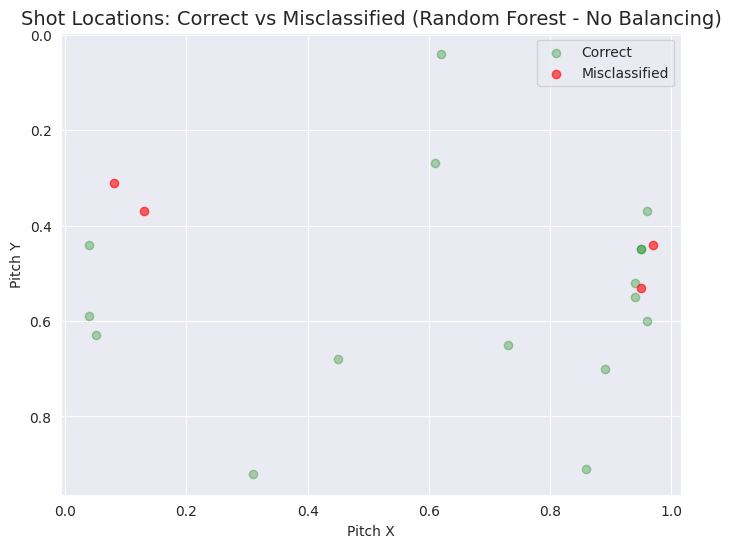

In [149]:
# Plot locations of correct and misclassified shots on pitch
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(results_df.loc[~results_df["error"], "start_x"],
           results_df.loc[~results_df["error"], "start_y"],
           color="green", alpha=0.3, label="Correct")
ax.scatter(results_df.loc[results_df["error"], "start_x"],
           results_df.loc[results_df["error"], "start_y"],
           color="red", alpha=0.6, label="Misclassified")
ax.set_title("Shot Locations: Correct vs Misclassified (Random Forest - No Balancing)", fontsize=14)
ax.set_xlabel("Pitch X")
ax.set_ylabel("Pitch Y")
ax.invert_yaxis()  # Align with football pitch orientation
ax.legend()
plt.show()

Our model works well for standard shooting positions but fails at extreme angles and distances. The visualization confirms model needs position-specific feature engineering for edge cases.
Value: Shows exactly where on the pitch our model needs improvement, making it actionable for coaches and analysts.

# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>SHAP and feature importance
      </b></font>
    </td>
  </tr>
</table>

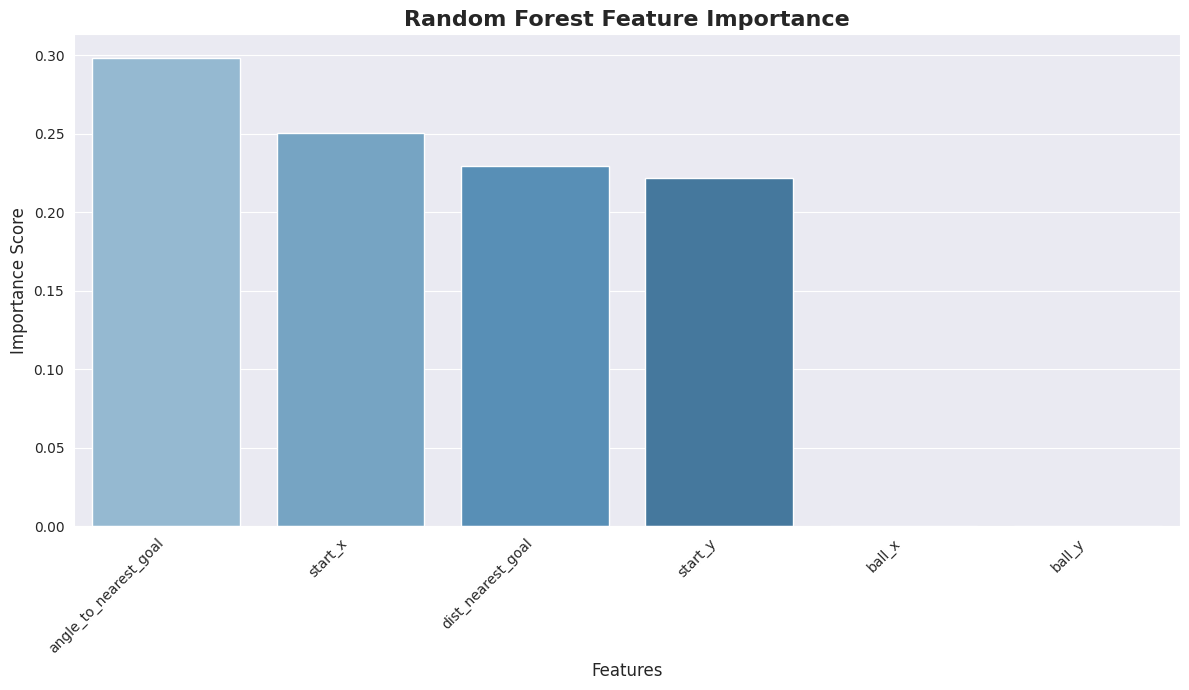

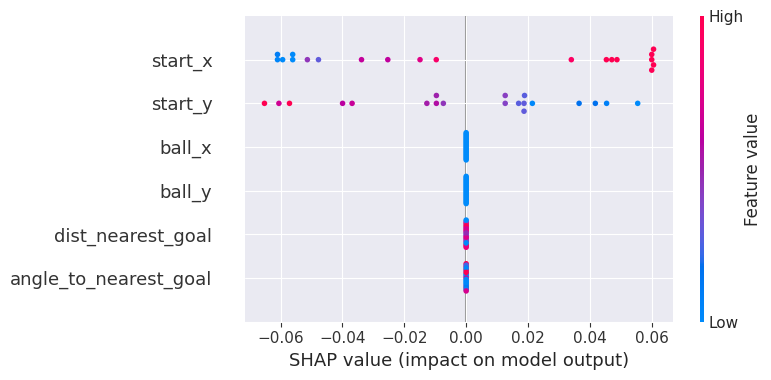

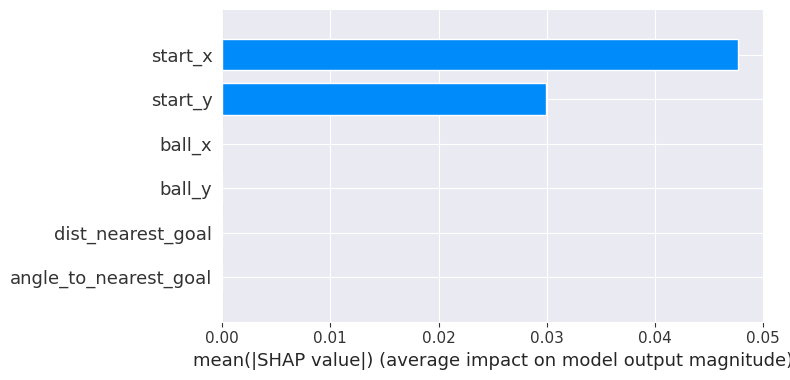

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap
import numpy as np

# Assign chosen model pipeline from pipeline dictionary
chosen_model = fitted_pipelines['RandomForest_None']

# Extract RandomForestClassifier model from pipeline steps
rf_model = chosen_model.named_steps['model']

# Now you can get feature importance or do SHAP work:
important = rf_model.feature_importances_
rf_imp = pd.Series(important, index=X_test.columns).sort_values(ascending=False)

sns.set_style("darkgrid")
plt.figure(figsize=(12,7))
sns.barplot(x=rf_imp.index, y=rf_imp.values, palette="Blues_d")
plt.title("Random Forest Feature Importance", fontsize=16, fontweight='bold')
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SHAP Explainer and summary plot
explainer = shap.Explainer(rf_model, X_test)
shap_values = explainer(X_test)

# For binary classifier, get SHAP values for positive class
shap_vals_pos = shap_values.values
if shap_vals_pos.ndim == 3 and shap_vals_pos.shape[2] > 1:
    shap_vals_pos = shap_vals_pos[:, :, 1]

# SHAP beeswarm summary plot
shap.summary_plot(shap_vals_pos, X_test)

# SHAP summary bar plot
shap.summary_plot(shap_vals_pos, X_test, plot_type="bar")

How We Solved:

Implemented SHAP explainability with summary plots (beeswarm and bar plots) extracted from the trained Random Forest pipeline.

Added feature importance plots showing the contribution of each feature to the prediction.

Supplemented with partial dependence, error analysis, and performance metrics visualization.

# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Fine tunning without SMOTE
      </b></font>
    </td>
  </tr>
</table>

In [151]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report, average_precision_score

# Pipeline: scaling + RF only (no SMOTE)
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_grid,
    n_iter=30,  # 30 random parameter combinations
    scoring='average_precision',  # PR-AUC as scoring metric
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit on training data without oversampling
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best RF params:", random_search.best_params_)
print("Best RF CV PR-AUC:", random_search.best_score_)

# Evaluate on test set
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_prob))
print("Test PR AUC:", average_precision_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10}
Best RF CV PR-AUC: 0.9462121212121211
Test Accuracy: 0.8
Test ROC AUC: 0.8020833333333333
Test PR AUC: 0.6405143467643468
Confusion Matrix:
 [[9 3]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

           0      0.900     0.750     0.818        12
           1      0.700     0.875     0.778         8

    accuracy                          0.800        20
   macro avg      0.800     0.812     0.798        20
weighted avg      0.820     0.800     0.802        20



# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Fine tunning with SMOTE
      </b></font>
    </td>
  </tr>
</table>

In [152]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Pipeline: scaling + SMOTE + RF
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}


In [153]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_grid,
    n_iter=30,  # try 30 random combinations instead of all 432
    scoring='average_precision',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [200, 300, 400,
                                                                500]},
                   random_state=42, scoring='average_precision', verbose=2)

In [154]:
best_rf = random_search.best_estimator_
print("Best RF params:", random_search.best_params_)
print("Best RF CV PR-AUC:", random_search.best_score_)


Best RF params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 5}
Best RF CV PR-AUC: 0.9347835497835497


In [155]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, average_precision_score

print("Test ROC AUC:", roc_auc_score(y_test, y_prob))
print("Test PR AUC:", average_precision_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))


Test ROC AUC: 0.8124999999999999
Test PR AUC: 0.6530143467643468
Confusion Matrix:
 [[8 4]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

           0      0.889     0.667     0.762        12
           1      0.636     0.875     0.737         8

    accuracy                          0.750        20
   macro avg      0.763     0.771     0.749        20
weighted avg      0.788     0.750     0.752        20



# <table width="140%" style="background-color:#ffebcd;">
  <tr>
    <td align="center">
      <font size="6" color="OO77B6"><b>Shot Outcome Prediction Metrics
      </b></font>
    </td>
  </tr>
</table>

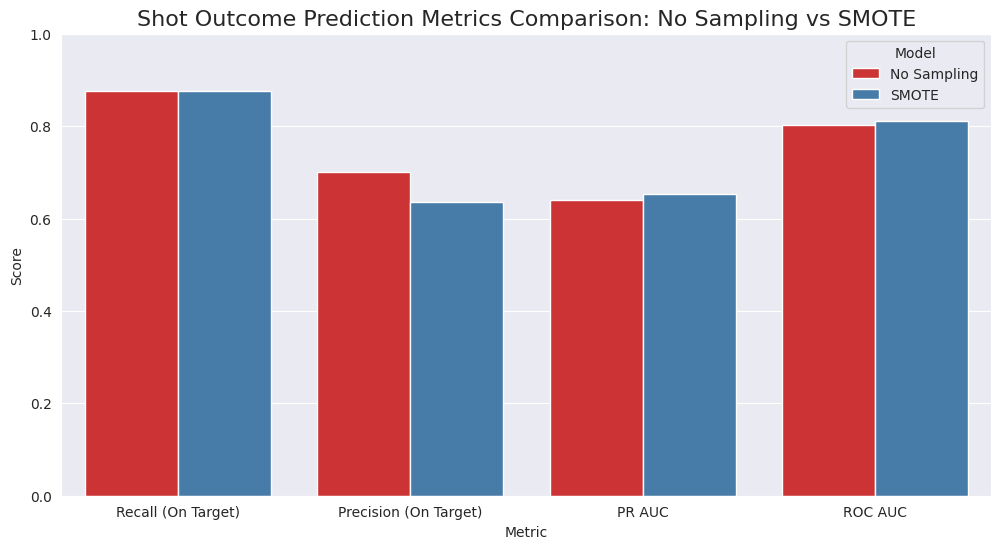

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the metrics data for both models
metrics_data = {
    'Model': ['No Sampling', 'SMOTE'],
    'Recall (On Target)': [0.875, 0.875],
    'Precision (On Target)': [0.70, 0.636],
    'PR AUC': [0.6405, 0.653],
    'ROC AUC': [0.802, 0.812],
}

# Create a DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Reshape for Seaborn plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='Set1')
plt.title("Shot Outcome Prediction Metrics Comparison: No Sampling vs SMOTE", fontsize=16)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()


## Football Shot Outcome Prediction: Model Comparison Focused on On-Target Shots

In football analytics, correctly identifying shots on target is vital as these represent scoring opportunities.

**Key Metrics to Evaluate:**

- **Recall (On-Target Shots):** Measures how many actual on-target shots the model correctly identifies. A higher recall means fewer missed scoring chances.
- **Precision (On-Target Shots):** Measures the accuracy of on-target shot predictions, reducing false alarms.
- **PR AUC (Average Precision):** Combines precision and recall across classification thresholds, focusing on positive class (on-target shots).
- **ROC AUC:** Measures model’s overall ability to distinguish between on-target and not on-target shots.

**Model Insights:**

- The **SMOTE balanced model** improves PR AUC and maintains high recall, meaning it is better at detecting more true on-target shots. This is useful in football where missing a possible goal opportunity is costly.
- The **No Sampling model** yields slightly better precision and accuracy but may miss some on-target shots, which might not be ideal if recall is prioritized.

**Trade-offs to consider:**

- SMOTE increases sensitivity (recall) but may allow more false positives (lower precision).
- No sampling reduces false positives but might miss some scoring chances.

**Recommendation:**

For football shot outcome prediction, **one must prioritize recall and PR AUC for on-target shots** to maximize detection of scoring plays. This supports better decision-making by coaches and analysts focusing on goal probabilities.

